# Cell 0 - vertex ai



In [1]:
# ============================================================
# CELL 0: VERTEX AI SETUP & CONNECTION TEST
# ============================================================
!pip install -q google-cloud-aiplatform openai

import json, tempfile, os
from google.colab import userdata
import google.auth
import google.auth.transport.requests
from google.oauth2 import service_account
from openai import OpenAI

# Load service account credentials
service_account_info = json.loads(userdata.get("GCP_SERVICE_ACCOUNT_JSON"))

# Get access token from service account
credentials = service_account.Credentials.from_service_account_info(
    service_account_info,
    scopes=["https://www.googleapis.com/auth/cloud-platform"]
)
auth_request = google.auth.transport.requests.Request()
credentials.refresh(auth_request)
access_token = credentials.token

# Vertex AI config
PROJECT_ID = "nth-celerity-488821-b3"
LOCATION = "us-east5"
VERTEX_MODEL_ID = "meta/llama-4-maverick-17b-128e-instruct-maas"

vertex_client = OpenAI(
    base_url=f"https://{LOCATION}-aiplatform.googleapis.com/v1/projects/{PROJECT_ID}/locations/{LOCATION}/endpoints/openapi",
    api_key=access_token
)

# Test connection
print("⏳ Testing Vertex AI Llama 4 connection...")
response = vertex_client.chat.completions.create(
    model=VERTEX_MODEL_ID,
    messages=[{"role": "user", "content": "Reply with just: OK"}],
    max_tokens=5
)
print(f"   Response: {response.choices[0].message.content.strip()}")
print("✅ Vertex AI Llama 4 Maverick connected successfully")

def refresh_vertex_credentials():
    """
    Refresh the Vertex AI access token.
    Call this if you get a 401 UNAUTHENTICATED error.
    Token expires after 1 hour in Colab.
    On GCP this is handled automatically — this is Colab-only.
    """
    global vertex_client, access_token

    credentials.refresh(auth_request)
    access_token = credentials.token

    vertex_client = OpenAI(
        base_url=f"https://{LOCATION}-aiplatform.googleapis.com/v1"
                 f"/projects/{PROJECT_ID}/locations/{LOCATION}"
                 f"/endpoints/openapi",
        api_key=access_token
    )
    print("✅ Vertex AI credentials refreshed")

print("💡 If you get a 401 error, run: refresh_vertex_credentials()")

⏳ Testing Vertex AI Llama 4 connection...
   Response: OK
✅ Vertex AI Llama 4 Maverick connected successfully
💡 If you get a 401 error, run: refresh_vertex_credentials()


# Cell 1 - dependencies - run once per session

In [ ]:
import pymupdf
print(pymupdf.__version__)

1.27.1


In [2]:
# ============================================================
# CELL 1: INSTALL ALL DEPENDENCIES
# ============================================================
# %%capture

# Step 1: Fix packaging version FIRST — PaddleOCR requires this
!pip install "packaging==23.2" -q

# Step 2: Clean slate for conflicting packages
!pip uninstall -y numpy paddlepaddle paddleocr torch transformers sentencepiece 2>/dev/null

# Step 3: Install numpy first — everything depends on it
!pip install numpy==1.26.4 -q

# Step 4: Core PDF and image libraries
!pip install pymupdf Pillow scipy -q

# Step 5: PaddlePaddle and PaddleOCR — order matters
!pip install paddlepaddle==2.6.2 -q
!pip install paddleocr==2.8.1 -q

# Step 6: PyTorch and transformers
!pip install torch==2.2.2 -q
!pip install transformers==4.38.2 sentencepiece -q

# Step 7: Remaining dependencies
!pip install groq -q
!pip install presidio-analyzer presidio-anonymizer -q
!pip install sacrebleu -q
!pip install bert-score -q
!pip install google-cloud-aiplatform openai -q

# Step 8: spaCy model
!python -m spacy download en_core_web_lg -q

print("\n" + "="*60)
print("✅ All dependencies installed")
print("="*60)

# # ============================================================
# # NEW CELL 1: SURGICAL DEPENDENCY INSTALL
# # ============================================================
# import os

# # 1. Force install the specific "Old Stack" needed for PaddleOCR
# # We combine these so pip resolves them together.
# !pip install --quiet --no-warn-conflicts \
#     "packaging==23.2" \
#     "numpy<2.0.0" \
#     "paddlepaddle-gpu==2.6.2" \
#     "paddleocr>=2.8.1" \
#     "torch==2.2.2" \
#     "torchvision==0.17.2" \
#     "transformers==4.38.2" \
#     "sentencepiece"

# # 2. Install the secondary tools
# !pip install --quiet \
#     groq \
#     presidio-analyzer presidio-anonymizer \
#     sacrebleu bert-score \
#     google-cloud-aiplatform openai \
#     pymupdf Pillow scipy

# # 3. Download spaCy model
# !python -m spacy download en_core_web_lg -q

# # 4. CRITICAL: Restart Runtime programmatically
# # This clears the "NumPy 2.0" currently loaded in memory and loads your 1.26 version.
# print("\n✅ Setup complete. RESTARTING RUNTIME to apply changes...")
# os.kill(os.getpid(), 9)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 2.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
wheel 0.46.3 requires packaging>=24.0, but you have packaging 23.2 which is incompatible.
db-dtypes 1.5.0 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.
xarray 2025.12.0 requires packaging>=24.1, but you have packaging 23.2 which is incompatible.
google-cloud-bigquery 3.40.1 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.
Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: transformers 5.0.0
Uninstalling transformers-5.0.0:
  Successfully uninstalled transformers-5.0.0


# Cell 2 - imports

In [2]:
# ============================================================
# CELL 2: IMPORTS & GLOBAL CONFIGURATION
# ============================================================
import os, re, json, time, tempfile
import numpy as np
import torch
import pymupdf
from PIL import Image, ImageDraw
from scipy.ndimage import sobel
from IPython.display import display, Image as IPImage
# import pytesseract

os.environ["PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK"] = "True"

# PaddleOCR
PaddleOCR = None
try:
    from paddleocr import PaddleOCR
    print("✅ PaddleOCR: available")
except Exception as e:
    print(f"⚠️  PaddleOCR unavailable: {e} — will fall back to Tesseract")

# Global constants
OCR_DPI              = 300
OCR_CONFIDENCE       = 0.50
WORK_DIR             = "/content/courtaccess_output"
os.makedirs(WORK_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n✅ Device: {device}")
print("✅ All imports ready")



✅ PaddleOCR: available

✅ Device: cuda
✅ All imports ready


# Cell 3 - pdf upload

In [71]:

# ============================================================
# CELL 3: UPLOAD PDF
# ============================================================
from pathlib import Path
from google.colab import files

print("📤 Upload a PDF to translate:")
try:
    uploaded = files.upload()
    if uploaded:
        fname = list(uploaded.keys())[0]
        pdf_path = Path(WORK_DIR) / fname
        pdf_path.write_bytes(uploaded[fname])
        INPUT_PDF = str(pdf_path)
        print(f"✅ Uploaded: {INPUT_PDF}")
except KeyboardInterrupt:
    INPUT_PDF = None
    print("Upload skipped.")

assert INPUT_PDF and "courtaccess_translated" not in INPUT_PDF, \
    "❌ INPUT_PDF points to a previous output — re-upload your original PDF."



📤 Upload a PDF to translate:


Saving test12.pdf to test12 (1).pdf
✅ Uploaded: /content/courtaccess_output/test12 (1).pdf


# Cell 4 - font utilities

In [4]:

# ============================================================
# CELL 4: FONT UTILITIES
# Maps PDF font names to PyMuPDF built-in codes.
# fit_fontsize() shrinks translated text to fit bounding boxes
# — critical because Spanish runs ~20-30% longer than English.
# ============================================================

FONT_MAP = {
    "Helvetica": "helv",           "Helvetica-Bold": "hebo",
    "Helvetica-Oblique": "heit",   "Helvetica-BoldOblique": "hebi",
    "Times-Roman": "tiro",         "Times-Bold": "tibo",
    "Times-Italic": "tiit",        "Times-BoldItalic": "tibi",
    "Courier": "cour",             "Courier-Bold": "cobo",
    "Courier-Oblique": "coit",     "Courier-BoldOblique": "cobi",
    "Symbol": "symb",              "ZapfDingbats": "zadb",
}

def get_font_code(span):
    """
    Map original span font to closest PyMuPDF built-in font.
    Preserves bold/italic style from original.
    """
    fontname = span.get("font", "")
    flags    = span.get("flags", 0)

    # Detect style from font name AND flags
    is_bold   = (
        bool(flags & 16) or
        any(w in fontname.lower() for w in
            ["bold", "black", "heavy", "demi"])
    )
    is_italic = (
        bool(flags & 2) or
        any(w in fontname.lower() for w in
            ["italic", "oblique", "slant"])
    )
    is_mono   = (
        bool(flags & 8) or
        any(w in fontname.lower() for w in
            ["courier", "mono", "typewriter", "fixed"])
    )
    is_serif  = (
        bool(flags & 4) or
        any(w in fontname.lower() for w in
            ["times", "serif", "nimbus", "georgia",
             "garamond", "palatino"])
    )

    # Map to closest built-in font preserving style
    if is_mono:
        if is_bold and is_italic: return "cobi"
        if is_bold:               return "cobo"
        if is_italic:             return "coit"
        return "cour"
    elif is_serif:
        if is_bold and is_italic: return "tibi"
        if is_bold:               return "tibo"
        if is_italic:             return "tiit"
        return "tiro"
    else:
        # Default: Helvetica family
        if is_bold and is_italic: return "hebi"
        if is_bold:               return "hebo"
        if is_italic:             return "heit"
        return "helv"

def get_font_size(span, min_size=6.0) -> float:
    """
    Extract exact font size from span.
    No arbitrary reduction — use original size directly.
    """
    return max(round(span.get("size", 10.0), 1), min_size)

def fit_fontsize(text, original_size, bbox_width, fontname="helv", min_size=4.0):
    font = pymupdf.Font(fontname)
    # If text fits at original size, never shrink
    if font.text_length(text, fontsize=original_size) <= bbox_width * 0.95:
        return original_size
    size = original_size
    while size >= min_size:
        if font.text_length(text, fontsize=size) <= bbox_width * 0.95:
            return size
        size -= 0.5
    return min_size

def estimate_fontsize(text, target_width, fontname="helv"):
    font = pymupdf.Font(fontname)
    best = 5.0
    for s10 in range(50, 260, 2):
        size = s10 / 10.0
        if font.text_length(text, fontsize=size) <= target_width:
            best = size
        else:
            break
    return best

def get_background_color(page, bbox):
    try:
        pix = page.get_pixmap(clip=pymupdf.Rect(bbox), matrix=pymupdf.Matrix(1, 1))
        s = pix.samples
        if len(s) >= 3:
            return (s[0]/255, s[1]/255, s[2]/255)
    except Exception:
        pass
    return (1, 1, 1)

def _safe_color(span) -> tuple:
    """
    Convert a PyMuPDF span's packed integer color to a (r, g, b)
    tuple with values in 0.0–1.0 range, as insert_text requires.

    Bypasses sRGB_to_rgb entirely — in some PyMuPDF builds it
    returns 0-255 integers instead of 0-1 floats, causing:
      ValueError: need 1, 3 or 4 color components in range 0 to 1

    The span "color" field is always a packed 24-bit integer:
      0x000000 = black, 0xFFFFFF = white, 0xFF0000 = red, etc.
    """
    if isinstance(span, dict):
        raw = span.get("color", 0)
    else:
        raw = span

    # Already a tuple — normalize just in case values are 0-255
    if isinstance(raw, (tuple, list)) and len(raw) >= 3:
        vals = [v / 255.0 if v > 1 else float(v) for v in raw[:3]]
        return tuple(vals)

    # Packed integer — decode manually
    try:
        n = int(raw)
    except (TypeError, ValueError):
        return (0.0, 0.0, 0.0)

    r = ((n >> 16) & 0xFF) / 255.0
    g = ((n >>  8) & 0xFF) / 255.0
    b = ( n        & 0xFF) / 255.0
    return (r, g, b)

print("✅ _safe_color ready")

print("✅ Font utilities ready")


✅ _safe_color ready
✅ Font utilities ready


# Cell 5 - page classifier

In [5]:
# ============================================================
# CELL 5: PAGE CLASSIFIER (fixed)
# DIGITAL     — real vector text, no background image
# SCANNED     — image-based page (with or without embedded OCR text)
# BLANK       — no text, no images
#
# Key fix: pages with high span count BUT a large background image
# are OCR'd scans, not true digital pages. We check image coverage
# to distinguish between them.
# ============================================================

def classify_page(page):
    td = page.get_text("dict", flags=pymupdf.TEXTFLAGS_TEXT)

    span_count = 0
    for b in td["blocks"]:
        if b["type"] == 0:
            for line in b["lines"]:
                for span in line["spans"]:
                    if span["text"].strip():
                        span_count += 1

    images   = page.get_images(full=True)
    drawings = page.get_drawings()
    page_area = page.rect.width * page.rect.height

    # ── Compute image coverage ────────────────────────────────
    total_img_area = 0
    for img in images:
        try:
            for r in page.get_image_rects(img[0]):
                total_img_area += r.width * r.height
        except Exception:
            pass

    # Fallback: use image block bboxes if get_image_rects fails
    if total_img_area == 0:
        for b in td["blocks"]:
            if b["type"] == 1:
                bb = b["bbox"]
                total_img_area += (bb[2] - bb[0]) * (bb[3] - bb[1])

    # Fallback: if images exist but we still can't measure, assume large
    if total_img_area == 0 and images:
        for img in images:
            if img[2] > 500 and img[3] > 500:  # width/height in pixels
                total_img_area = page_area * 0.85
                break

    img_coverage = total_img_area / page_area if page_area > 0 else 0

    # ── Classification logic ──────────────────────────────────

    # Blank: no text, no images
    if span_count == 0 and not images:
        return {
            "page_type": "BLANK",
            "is_scanned": False,
            "span_count": span_count,
            "images": len(images),
            "drawings": len(drawings),
            "img_coverage": round(img_coverage * 100, 1),
        }

    # OCR'd scan: has text spans BUT a large background image
    # (scanner embedded OCR text on top of the image)
    # Also catches pure scans with no text
    if img_coverage > 0.4 or (images and span_count == 0):
        return {
            "page_type": "SCANNED",
            "is_scanned": True,
            "span_count": span_count,
            "images": len(images),
            "drawings": len(drawings),
            "img_coverage": round(img_coverage * 100, 1),
        }

    # True digital: real vector text, no background image
    if span_count > 5:
        return {
            "page_type": "DIGITAL",
            "is_scanned": False,
            "span_count": span_count,
            "images": len(images),
            "drawings": len(drawings),
            "img_coverage": round(img_coverage * 100, 1),
        }

    # Fallback: treat as scanned if very few spans
    return {
        "page_type": "SCANNED",
        "is_scanned": True,
        "span_count": span_count,
        "images": len(images),
        "drawings": len(drawings),
        "img_coverage": round(img_coverage * 100, 1),
    }


def is_content_image(info):
    # Pure image with no readable text — preserve as-is
    return info["img_coverage"] > 80 and info["span_count"] < 5


print("✅ Page classifier ready")

✅ Page classifier ready


In [6]:
import pymupdf

doc = pymupdf.open("test9.pdf")  # replace with your actual filename
page = doc[0]
td = page.get_text("dict")
blocks = [b for b in td["blocks"] if b["type"] == 0]
print(f"Total blocks: {len(blocks)}")
for i, b in enumerate(blocks):
    first_text = b["lines"][0]["spans"][0]["text"][:60]
    bbox = b["bbox"]
    print(f"Block {i}: bbox={bbox} | text='{first_text}'")

Total blocks: 37
Block 0: bbox=(19.41699981689453, 773.6849975585938, 39.43300247192383, 784.3329467773438) | text='12.18'
Block 1: bbox=(19.41699981689453, 631.9019775390625, 233.72201538085938, 641.218994140625) | text=' ATTORNEY FOR PLAINTIFF (OR UNREPRESENTED PLAINTIFF) '
Block 2: bbox=(19.41699981689453, 644.469970703125, 300.1949157714844, 660.4420166015625) | text='  '
Block 3: bbox=(19.41899871826172, 664.114013671875, 299.6429138183594, 680.0860595703125) | text=' _________________________________________ '
Block 4: bbox=(19.41899871826172, 683.7579956054688, 299.6429138183594, 699.7300415039062) | text=' _________________________________________ '
Block 5: bbox=(19.41899871826172, 703.4019775390625, 299.6429138183594, 719.3740234375) | text=' _________________________________________ '
Block 6: bbox=(56.000999450683594, 24.559024810791016, 217.3409881591797, 55.687049865722656) | text='STATEMENT OF DAMAGES '
Block 7: bbox=(253.41700744628906, 19.90196990966797, 300.8700561523

# Cell 6 - NLLB translation

In [7]:
# ============================================================
# CELL 6: NLLB-200 1.3B TRANSLATION SETUP
#
# Architecture:
#   1. Blank line detection — underscore/dash fill-ins preserved
#   2. spaCy NER protects proper nouns from hallucination
#   3. Citation extractor protects §, G.L. c., URLs, form codes
#   4. NLLB translates clean text
#   5. Placeholders restored in output
#   6. Court name post-translation lookup
#
# No hardcoded skip lists — dynamic protection only.
# ============================================================
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import spacy
import re

# ── Load NLLB ────────────────────────────────────────────────
MODEL_NAME  = "facebook/nllb-200-distilled-1.3B"
SOURCE_LANG = "eng_Latn"
TARGET_LANG = "spa_Latn"

print("⏳ Loading NLLB-200 1.3B...")
nllb_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
nllb_model     = AutoModelForSeq2SeqLM.from_pretrained(
    MODEL_NAME
).to(device)
nllb_model.eval()
print("✅ NLLB-200 1.3B ready")

# ── Load spaCy ───────────────────────────────────────────────
print("⏳ Loading spaCy NER...")
nlp = spacy.load("en_core_web_lg")
print("✅ spaCy NER ready")

# ── Citation patterns to protect before NLLB ─────────────────
CITATION_PATTERNS = [
    r"G\.L\.\s+c\.\s+[\d]+[A-Za-z]?",
    r"M\.G\.L\.\s+c\.\s+\d+",
    r"§\s*\d+[A-Za-z]*",
    r"Mass\.\s+R\.\s+\w+\.\s*P\.\s*\d+",
    r"\d+\s+U\.S\.C\.\s+§?\s*\d+",
    r"P\.\s*\d+\.\d+",
    r"(?<!\w)\d{4}-\w+-\d+(?!\w)",
    r"TC\d+\s*\(\d+\.\d+\)",
    r"TC\d+",
    r"LC-[A-Z\-]+",
    r"https?://\S+",
    r"www\.\S+",
    r"\b[A-Z]{2,}-\d+\b",
]

# ── Known court name translations ────────────────────────────
# Applied AFTER translation to fix spaCy-protected court names
COURT_NAME_TRANSLATIONS = {
    "Massachusetts Trial Court":  "Tribunal de Justicia de Massachusetts",
    "Land Court Department":      "Departamento del Tribunal de Tierras",
    "Land Court":                 "Tribunal de Tierras",
    "Trial Court":                "Tribunal de Justicia",
    "Boston Municipal Court":     "Tribunal Municipal de Boston",
    "District Court":             "Tribunal de Distrito",
    "Superior Court":             "Tribunal Superior",
    "Appeals Court":              "Tribunal de Apelaciones",
    "Supreme Judicial Court":     "Tribunal Supremo Judicial",
    "Housing Court":              "Tribunal de Vivienda",
    "Juvenile Court":             "Tribunal de Menores",
    "Probate Court":              "Tribunal de Sucesiones",
    "Lower Court":                "Tribunal Inferior",
}

def _extract_court_names(text: str) -> tuple:
    """
    Extract court names BEFORE NLLB using RFCN placeholders.
    Placeholders restore directly to verified SPANISH equivalents,
    so neither NLLB nor Llama can mistranslate them.
    Sorted longest-first to prevent partial matches.
    """
    placeholders = {}
    protected    = text
    counter      = 0
    for en_name in sorted(COURT_NAME_TRANSLATIONS.keys(),
                          key=lambda x: -len(x)):
        matches = list(re.finditer(
            re.escape(en_name), protected, re.IGNORECASE
        ))
        for m in reversed(matches):
            key               = f"RFCN{counter}RF"
            placeholders[key] = COURT_NAME_TRANSLATIONS[en_name]
            protected         = (
                protected[:m.start()] + key + protected[m.end():]
            )
            counter += 1
    return protected, placeholders


def _is_blank_fill_line(text: str) -> bool:
    """
    Detect blank fill-in lines — sequences of underscores or
    dashes used as form fill-in fields.
    These should be preserved exactly as-is.
    Examples: '_______________', '- - - - - - -'
    Does NOT match mixed lines like '___ (street address)' —
    those have translatable content.
    """
    t = text.strip()
    if not t:
        return True
    # Pure underscore/dash/space lines
    if re.match(r'^[\s_\-]{4,}$', t):
        return True
    if re.match(r'^\$[\s_\-\.]{3,}$', t):
        return True
    # Lines that are MOSTLY underscores (>80% of chars)
    non_blank = re.sub(r'[\s_\-]', '', t)
    if len(non_blank) == 0:
        return True
    return False


def _extract_citations(text: str) -> tuple:
    """
    Find citation patterns, replace with alphanumeric placeholders.
    Returns (protected_text, {placeholder: original})
    Old format: {{CITE_0}}  →  New format: RFCT0RF
    """
    placeholders = {}
    protected    = text
    counter      = 0

    for pattern in CITATION_PATTERNS:
        matches = list(re.finditer(pattern, protected))
        for m in reversed(matches):
            key               = f"RFCT{counter}RF"
            placeholders[key] = m.group(0)
            protected         = (
                protected[:m.start()] + key + protected[m.end():]
            )
            counter += 1

    return protected, placeholders


def _extract_proper_nouns(text: str) -> tuple:
    """
    Use spaCy NER to protect proper nouns.
    Old format: {{PROP_0}}  →  New format: RFPN0RF
    """
    doc          = nlp(text)
    placeholders = {}
    protected    = text
    counter      = 0

    entities = sorted(
        doc.ents, key=lambda e: e.start_char, reverse=True
    )

    for ent in entities:
        if ent.label_ not in ("PERSON", "GPE", "LOC",
                               "ORG", "PRODUCT", "NORP"):
            continue

        ent_text = ent.text.strip()

        if len(ent_text) < 3:
            continue

        words = ent_text.split()
        has_function = any(
            w.lower() in {
                "the", "of", "in", "at", "for", "and",
                "or", "a", "an", "by", "to", "from"
            }
            for w in words if not w[0].isupper()
        )
        if has_function:
            continue

        key               = f"RFPN{counter}RF"
        placeholders[key] = ent_text
        protected         = (
            protected[:ent.start_char]
            + key
            + protected[ent.end_char:]
        )
        counter += 1

    return protected, placeholders

def _restore_placeholders(text: str, *dicts) -> str:
    """
    Restore all placeholders to original values.
    Uses regex to handle cases where NLLB inserts spaces
    inside the token (e.g. RFCT 0 RF or R F C T 0 R F).
    """
    result = text
    for d in dicts:
        for key, original in d.items():
            # Try direct match first (most common case)
            if key in result:
                result = result.replace(key, original)
                continue
            # Regex fallback: allow spaces between any chars
            # e.g. RFCT0RF → matches "RFCT 0 RF" or "RFCT0 RF"
            # Build pattern from key: insert \s* between each char group
            num = re.search(r'\d+', key)
            if num:
                prefix = key[:key.index(num.group())]
                suffix = key[key.index(num.group()) + len(num.group()):]
                pattern = (re.escape(prefix) + r'\s*'
                           + num.group() + r'\s*'
                           + re.escape(suffix))
                result = re.sub(
                    pattern, lambda m, o=original: o,
                    result, flags=re.IGNORECASE
                )
    return result


def _translate_court_names(text: str) -> str:
    """
    Post-translation step: replace English court names that
    spaCy protected (and restored) with verified Spanish.
    Sorted by length to match longer names first.
    """
    result = text
    for en, es in sorted(
        COURT_NAME_TRANSLATIONS.items(), key=lambda x: -len(x[0])
    ):
        result = re.sub(
            re.escape(en), es, result, flags=re.IGNORECASE
        )
    return result

def _is_preserve_only(text: str) -> bool:
    """
    Returns True if text is only placeholders/numbers/punctuation
    with no real words to translate.
    Updated to match new RFCT/RFPN token format.
    """
    stripped = text.strip()
    if not stripped:
        return True
    # Remove new-format placeholders
    cleaned = re.sub(r"RFCT\d+RF|RFPN\d+RF", "", stripped)
    cleaned = re.sub(r"[\d\s\.\-\/\(\)\,\;\:\#\@\!\?]+", "", cleaned)
    return len(cleaned.strip()) == 0

def _raw_batch_translate(texts: list) -> list:
    nllb_tokenizer.src_lang = SOURCE_LANG
    enc = nllb_tokenizer(
        texts, return_tensors="pt", padding=True,
        truncation=True, max_length=512
    ).to(device)
    gen = nllb_model.generate(
        **enc,
        forced_bos_token_id=nllb_tokenizer.convert_tokens_to_ids(
            TARGET_LANG
        ),
        max_length=min(512, enc["input_ids"].shape[1] + 60),
        num_beams=4,
        early_stopping=True,
    )
    return nllb_tokenizer.batch_decode(
        gen, skip_special_tokens=True
    )

def translate_one(text: str) -> str:
    if not text or not text.strip():
        return text

    # Step 0: preserve blank fill-in lines
    if _is_blank_fill_line(text):
        return text

    # Step 0.5: hard-coded single-token form field labels
    _FORM_TOKENS = {
        "DATE": "FECHA", "SIGNATURE": "FIRMA",
        "PRINT": "IMPRIMIR", "CLEAR": "BORRAR",
        "SUBMIT": "ENVIAR", "COUNTY": "CONDADO",
        "SIGN": "FIRMAR",
    }
    if text.strip().upper() in _FORM_TOKENS:
        return _FORM_TOKENS[text.strip().upper()]

    # Step 1: protect citations
    protected, cite_map = _extract_citations(text)

    # Step 1.5: protect court names → restore as verified Spanish
    protected, court_map = _extract_court_names(protected)

    # Step 2: protect proper nouns with spaCy
    protected, prop_map = _extract_proper_nouns(protected)

    # Step 3: if nothing left to translate, restore and return
    if _is_preserve_only(protected):
        return _restore_placeholders(text, cite_map, court_map, prop_map)

    # Step 4: NLLB translates
    try:
        translated_raw = _raw_batch_translate([protected])[0]
    except Exception as e:
        print(f"   ⚠️  NLLB error: {e} — keeping original")
        return text

    # Step 5: restore all placeholders
    translated = _restore_placeholders(
        translated_raw, cite_map, court_map, prop_map
    )

    # Step 6: catch any remaining untranslated court names
    translated = _translate_court_names(translated)

    # Step 7: hallucination guard (threshold 2.5)
    ratio = len(translated) / max(len(text), 1)
    if ratio > 2.5 or ratio < 0.1:
        print(f"   ⚠️  Hallucination (ratio={ratio:.1f}): "
              f"'{text[:50]}' → keeping original")
        return text

    return translated

def batch_translate(texts: list) -> list:
    """Translate a list of texts through the full pipeline."""
    return [translate_one(t) for t in texts]

def split_into_sentences(text: str) -> list:
    """Split text into sentences for granular translation."""
    sentences = re.split(r"(?<=[.!?])\s+", text.strip())
    return [s for s in sentences if s.strip()]

print("✅ Translation pipeline ready")
print("   Protection: blank line detection + spaCy NER "
      "+ citation extraction + court name lookup")

⏳ Loading NLLB-200 1.3B...


tokenizer_config.json:   0%|          | 0.00/564 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/4.85M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.3M [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/808 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/5.48G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

✅ NLLB-200 1.3B ready
⏳ Loading spaCy NER...
✅ spaCy NER ready
✅ Translation pipeline ready
   Protection: blank line detection + spaCy NER + citation extraction + court name lookup


In [ ]:
# ============================================================
# TEMP TEST: Translation protection pipeline
# ============================================================
test_cases = [
    "The defendant waived their rights under G.L. c. 263, § 6.",
    "MASSACHUSETTS",
    "Massachusetts Trial Court",
    "TC0051 (1.24)",
    "The Commonwealth proved beyond a reasonable doubt.",
    "Plaintiff filed a complaint for partition.",
    "DATE SIGNATURE OF DEFENDANT",
    "BBO NO.",
    "LC-MISC-NOTPAR (09/25) www.mass.gov/courts/landcourt",
    "I, the above-named defendant, have been informed of "
    "my right to be tried by a jury of six persons.",
    "land court"
]

print("🧪 Translation protection test:\n")
for text in test_cases:
    result = translate_one(text)
    changed = "→ " + result if result != text else "→ [unchanged]"
    print(f"  EN: {text[:70]}")
    print(f"  ES: {result[:70]}")
    print()

🧪 Translation protection test:

  EN: The defendant waived their rights under G.L. c. 263, § 6.
  ES: El demandado renunció a sus derechos bajo G.L. c. 263, § 6.

  EN: MASSACHUSETTS
  ES: MASSACHUSETTS

  EN: Massachusetts Trial Court
  ES: Massachusetts Trial Court

  EN: TC0051 (1.24)
  ES: TC0051 (1.24)

  EN: The Commonwealth proved beyond a reasonable doubt.
  ES: La Commonwealth demostró más allá de toda duda razonable.

  EN: Plaintiff filed a complaint for partition.
  ES: El demandante presentó una queja por partición.

  EN: DATE SIGNATURE OF DEFENDANT
  ES: Fecha Firma del demandado

  EN: BBO NO.
  ES: BBO No.

  EN: LC-MISC-NOTPAR (09/25) www.mass.gov/courts/landcourt
  ES: LC-MISC-NOTPAR (09/25) www.mass.gov/courts/landcourt

  EN: I, the above-named defendant, have been informed of my right to be tri
  ES: Yo, el acusado mencionado, he sido informado de mi derecho a ser juzga

  EN: land court
  ES: land court



# Cell 7a - Legal Glossary

In [8]:
# ============================================================
# CELL 7A: LEGAL GLOSSARY LOADER
# Downloads NJ Courts English/Spanish glossary PDF,
# parses term pairs automatically, caches as JSON.
# On GCP: swap WORK_DIR paths for GCS bucket paths.
# ============================================================
import urllib.request
import json
import re
import os
import shutil

SPANISH_GLOSSARY_URL  = "https://www.njcourts.gov/sites/default/files/forms/11783_glossary_spanish.pdf"
SPANISH_GLOSSARY_PDF  = os.path.join(WORK_DIR, "glossary_spanish.pdf")
SPANISH_GLOSSARY_JSON = os.path.join(WORK_DIR, "glossary_es.json")

# ── MA-specific overrides ─────────────────────────────────────
MA_OVERRIDES_ES = {
    "commonwealth":              "Commonwealth",
    "g.l. c.":                   "G.L. c.",
    "beyond a reasonable doubt": "más allá de una duda razonable",
    "mandatory minimum":         "mínimo obligatorio",
    "municipal court":           "Tribunal Municipal",
    "waiver":                    "renuncia",
    "waive":                     "renunciar",
    "plea":                      "declaración",
    "defendant":                 "acusado",
    "plaintiff":                 "demandante",
    "juror":                     "miembro del jurado",
    "right to counsel":          "derecho a la asistencia letrada",
    "due process":               "debido proceso",
    "contempt":                  "desacato",
    "counsel":                   "abogado",
    "public defender":           "defensor público",
    "verdict":                   "veredicto",
    "trial court":               "Tribunal de Justicia",
    "party":                     "parte",
    "party(s)":                  "parte(s)",
    "notice":                    "aviso",
    "partition":                 "partición",
    "child":                     "menor",
}

SKIP_LINES = {
    "glossary of legal", "revised", "revisado",
    "cn 11783", "a , b , c",
    "introduction", "the primary purpose", "this document",
    "the glossary is not", "wrong and unacceptable",
    "one correct way", "benefit.", "for all the only",
    "promote uniform", "when working on",
    "issues official", "updated each time",
}

def _should_skip(text: str, y0: float) -> bool:
    if y0 < 55 or y0 > 725:
        return True
    t = text.lower().strip()
    if not t:
        return True
    if len(t) <= 2 and t.isalpha():
        return True
    if any(t.startswith(skip) for skip in SKIP_LINES):
        return True
    return False

def parse_spanish_glossary(pdf_path: str) -> dict:
    """
    Parse NJ Courts English/Spanish glossary PDF.
    Structure: each entry = one block with two lines.
      Line 1 = English term
      Line 2 = Spanish translation
    Returns dict: {english_term_lower: spanish_translation}
    """
    doc      = pymupdf.open(pdf_path)
    glossary = {}

    for pg_num in range(2, len(doc)):
        page = doc[pg_num]
        td   = page.get_text("dict")

        for b in td["blocks"]:
            if b["type"] != 0:
                continue

            b_y0 = round(b["bbox"][1], 1)

            if b_y0 < 55 or b_y0 > 725:
                continue

            lines = []
            for line in b["lines"]:
                text = " ".join(
                    s["text"] for s in line["spans"]
                ).strip()
                if text:
                    lines.append(text)

            if not lines:
                continue

            if _should_skip(lines[0], b_y0):
                continue

            if len(lines) == 1:
                continue

            elif len(lines) == 2:
                en = lines[0].strip()
                es = lines[1].strip()
                if en and es:
                    en_clean = en.strip(" ,;")
                    glossary[en_clean.lower()] = es

            elif len(lines) >= 3:
                line_x0s = []
                for line in b["lines"]:
                    text = " ".join(
                        s["text"] for s in line["spans"]
                    ).strip()
                    if text:
                        line_x0s.append(
                            round(line["bbox"][0], 1)
                        )

                left_lines  = []
                right_lines = []
                for line, x0 in zip(
                    [l for l in b["lines"]
                     if " ".join(
                         s["text"] for s in l["spans"]
                     ).strip()],
                    line_x0s
                ):
                    text = " ".join(
                        s["text"] for s in line["spans"]
                    ).strip()
                    if x0 < 200:
                        left_lines.append(text)
                    else:
                        right_lines.append(text)

                if left_lines and right_lines:
                    en = " ".join(left_lines).strip()
                    es = " ".join(right_lines).strip()
                else:
                    en = left_lines[0] if left_lines else lines[0]
                    es = " ".join(
                        (left_lines[1:] if left_lines else lines[1:])
                    ).strip()

                if en and es:
                    en_clean = en.strip(" ,;")
                    glossary[en_clean.lower()] = es

    doc.close()

    glossary.update(
        {k.lower(): v for k, v in MA_OVERRIDES_ES.items()}
    )

    print(f"   📊 Parsed {len(glossary)} term pairs from PDF")
    return glossary

def load_glossary_es(force_reparse: bool = False) -> dict:
    """
    Load Spanish glossary.
    If glossary PDF is already in WORK_DIR, parses it directly.
    Uses cached JSON if available and force_reparse=False.
    On GCP: replace file I/O with GCS read/write.
    """
    # Use cached JSON if available
    if not force_reparse and os.path.exists(SPANISH_GLOSSARY_JSON):
        with open(SPANISH_GLOSSARY_JSON, "r", encoding="utf-8") as f:
            glossary = json.load(f)
        print(f"   📚 Loaded from cache: {len(glossary)} terms")
        return glossary

    # Check if PDF already uploaded manually
    if not os.path.exists(SPANISH_GLOSSARY_PDF):
        print("   ❌ Glossary PDF not found.")
        print("   📤 Please upload it using this code:\n")
        print("   from google.colab import files")
        print("   import shutil")
        print("   uploaded = files.upload()")
        print("   fname = list(uploaded.keys())[0]")
        print(f"   shutil.copy(fname, '{SPANISH_GLOSSARY_PDF}')")
        print("\n   Then re-run this cell.")
        print("   Falling back to MA overrides only for now...")
        glossary = {
            k.lower(): v for k, v in MA_OVERRIDES_ES.items()
        }
        return glossary

    # Parse PDF
    print("   ⏳ Parsing glossary PDF...")
    glossary = parse_spanish_glossary(SPANISH_GLOSSARY_PDF)

    # Cache as JSON
    with open(SPANISH_GLOSSARY_JSON, "w", encoding="utf-8") as f:
        json.dump(glossary, f, ensure_ascii=False, indent=2)
    print(f"   ✅ Cached: {SPANISH_GLOSSARY_JSON}")

    return glossary

def get_matching_glossary_terms(
    text: str,
    glossary: dict,
    max_terms: int = 8
) -> dict:
    """
    Find glossary terms appearing in a text span.
    Returns only matching pairs.
    Longer terms matched first to avoid partial overlaps.
    """
    text_lower = text.lower()
    matches    = {}
    for en_term in sorted(glossary.keys(), key=len, reverse=True):
        if en_term in text_lower:
            matches[en_term] = glossary[en_term]
        if len(matches) >= max_terms:
            break
    return matches

# ── Upload PDF if not present, then load ─────────────────────
os.makedirs(WORK_DIR, exist_ok=True)

if not os.path.exists(SPANISH_GLOSSARY_PDF):
    print("📤 Glossary PDF not found — please upload it:")
    from google.colab import files
    uploaded = files.upload()
    if uploaded:
        fname = list(uploaded.keys())[0]
        shutil.copy(fname, SPANISH_GLOSSARY_PDF)
        print(f"✅ Saved to {SPANISH_GLOSSARY_PDF}")

# ── Load glossary ─────────────────────────────────────────────
print("⏳ Loading Spanish legal glossary...")
GLOSSARY_ES = load_glossary_es(force_reparse=True)
print(f"✅ Spanish glossary ready: {len(GLOSSARY_ES)} terms")

# ── Sanity check ──────────────────────────────────────────────
print("\n📋 Sanity check — key terms:")
test_terms = [
    "arraignment", "bail", "defendant (civil)",
    "defendant (criminal)", "waiver", "affidavit",
    "bench warrant", "beyond a reasonable doubt",
    "plea", "probation", "trial court",
]
for t in test_terms:
    es     = GLOSSARY_ES.get(t, "NOT FOUND")
    status = "✅" if es != "NOT FOUND" else "❌"
    print(f"   {status} {t:40s} → {es}")

found = sum(
    1 for t in test_terms
    if GLOSSARY_ES.get(t) != "NOT FOUND"
)
print(f"\n   {found}/{len(test_terms)} test terms found")
print(f"   Total glossary size: {len(GLOSSARY_ES)} terms")

📤 Glossary PDF not found — please upload it:


Saving 11783_glossary_spanish.pdf to 11783_glossary_spanish.pdf
✅ Saved to /content/courtaccess_output/glossary_spanish.pdf
⏳ Loading Spanish legal glossary...
   ⏳ Parsing glossary PDF...
   📊 Parsed 739 term pairs from PDF
   ✅ Cached: /content/courtaccess_output/glossary_es.json
✅ Spanish glossary ready: 739 terms

📋 Sanity check — key terms:
   ✅ arraignment                              → lectura de cargos, instrucción de cargos
   ✅ bail                                     → fianza, caución
   ✅ defendant (civil)                        → demandado (en una acción civil)
   ✅ defendant (criminal)                     → acusado (en una causa penal)
   ✅ waiver                                   → renuncia
   ✅ affidavit                                → Affidávit, afidávit, declaración jurada (por escrito)
   ✅ bench warrant                            → orden de busca y captura/ de detención (emitida verbalmente por el juez debido a incomparecencia)
   ✅ beyond a reasonable doubt       

# Cell 7 - Llama 4 context verification

In [9]:
# ============================================================
# CELL 7: VERTEX AI LLAMA 4 LEGAL VERIFICATION
#
# Two modes:
#   DOCUMENT — all sentences verified in one batch per page
#   AUDIO    — only glossary-matched utterances verified
#
# Llama 4 is the PRIMARY context and meaning checker.
# Glossary is SECONDARY — injected as reference only.
# No HIGH_RISK_PATTERNS — Llama sees everything in document mode.
# ============================================================

VERIFICATION_MODE = "document"  # "document" or "audio"

def _strip_fences(text: str) -> str:
    text = text.strip()
    for prefix in ("```json", "```"):
        if text.startswith(prefix):
            text = text[len(prefix):]
    if text.endswith("```"):
        text = text[:-3]
    return text.strip()

def _build_glossary_snippet(texts: list) -> str:
    """
    Find glossary terms appearing in a list of texts.
    Returns compact reference string for the Llama prompt.
    Only injects matching terms — not the full glossary.
    Longer terms matched first to avoid partial overlaps.
    """
    combined = " ".join(texts).lower()
    matches  = {}
    for en_term in sorted(GLOSSARY_ES.keys(), key=len, reverse=True):
        if en_term in combined:
            matches[en_term] = GLOSSARY_ES[en_term]
        if len(matches) >= 15:
            break
    if not matches:
        return ""
    return "\n".join(
        f"  {en} → {es}" for en, es in matches.items()
    )

def _call_llama(
    original_batch: list,
    translated_batch: list,
    glossary_snippet: str
) -> list:
    """
    Send one batch of (original, translation) pairs to Llama 4.
    Returns list of verified translations, same length as input.
    Falls back to NLLB output on any error.
    Auto-refreshes token on 401.
    """
    pairs = "\n".join(
        f"{k+1}. EN: {o}\n   ES: {t}"
        for k, (o, t) in enumerate(
            zip(original_batch, translated_batch)
        )
    )

    glossary_section = ""
    if glossary_snippet:
        glossary_section = (
            "\nREFERENCE GLOSSARY — verified legal translations "
            "for terms found in this batch. Use as a guide, "
            "not a strict constraint. Prefer natural legal "
            "Spanish that preserves meaning over forced "
            "glossary terms:\n"
            f"{glossary_snippet}\n"
        )

    prompt = (
        "You are a certified legal translator specializing in "
        "English to Spanish court document translation.\n"
        f"{glossary_section}\n"
        "For each numbered pair below, verify the Spanish "
        "translation. Your PRIMARY goal is to ensure the full "
        "legal meaning and context of the English text is "
        "preserved accurately in Spanish.\n\n"
        "Rules:\n"
        "1. Preserve legal citations, § symbols, case numbers, "
        "statute references, URLs, and form codes EXACTLY as-is\n"
        "2. Use the glossary as a reference guide — but prefer "
        "natural legal Spanish over forced glossary terms if the "
        "NLLB translation already captures the meaning correctly\n"
        "3. Preserve proper nouns (people, places, organizations) "
        "exactly as written\n"
        "4. Only correct genuine legal meaning errors — do NOT "
        "change translations for stylistic preference alone\n"
        "5. If a translation is already legally accurate, "
        "return it UNCHANGED\n"
        "6. Short field labels like DATE, SIGNATURE, BBO NO. "
        "should be translated as standard Spanish form field "
        "labels\n"
        "7. Do NOT capitalize common nouns like juez, jurado, "
        "tribunal mid-sentence. Only capitalize proper nouns and "
        "the first word of a sentence\n"
        "8. For form field abbreviations like BBO NO., preserve "
        "the abbreviation order — translate as 'BBO Núm.' "
        "not 'Núm. BBO'\n"
        "9. For civil cases (partition, divorce, property), use "
        "'demandante' for plaintiff and 'demandado' for defendant. "
        "For criminal cases, use 'acusado' for defendant. "
        "Determine context from the document content\n"
        "10. 'notice' in a legal filing header means 'aviso' or "
        "'notificación' — both are acceptable\n"
        "Return ONLY a JSON array of verified Spanish strings, "
        "one per pair, in the same order. "
        "No explanation, no markdown, just the JSON array.\n\n"
        f"PAIRS:\n{pairs}\n\n"
        'Return format: ["verified 1", "verified 2", ...]'
    )

    try:
        resp = vertex_client.chat.completions.create(
            model=VERTEX_MODEL_ID,
            messages=[{"role": "user", "content": prompt}],
            temperature=0.1,
            max_tokens=2048,
        )
        corrected = json.loads(
            _strip_fences(resp.choices[0].message.content)
        )

        if isinstance(corrected, list) \
                and len(corrected) == len(original_batch):
            # Validate each result — reject if ratio is extreme
            validated = []
            for orig, trans, corr in zip(
                original_batch, translated_batch, corrected
            ):
                if not corr or not corr.strip():
                    validated.append(trans)
                    continue
                ratio = len(corr) / max(len(trans), 1)
                if 0.2 <= ratio <= 5.0:
                    validated.append(corr.strip())
                else:
                    validated.append(trans)
            return validated
        else:
            print(f"   ⚠️  Llama length mismatch — "
                  f"keeping NLLB output")
            return translated_batch

    except Exception as e:
        err_str = str(e)
        if "401" in err_str \
                or "UNAUTHENTICATED" in err_str \
                or "ACCESS_TOKEN_EXPIRED" in err_str:
            print("   🔄 Token expired — refreshing credentials...")
            try:
                refresh_vertex_credentials()
                # Retry once with fresh token
                return _call_llama(
                    original_batch,
                    translated_batch,
                    glossary_snippet
                )
            except Exception as e2:
                print(f"   ⚠️  Retry failed: {e2} "
                      f"— keeping NLLB output")
        else:
            print(f"   ⚠️  Llama error: {e} "
                  f"— keeping NLLB output")
        return translated_batch


def verify_page_translations(
    original_spans: list,
    translated_spans: list,
    batch_size: int = 16
) -> list:
    """
    Verify translations using Llama 4.

    DOCUMENT mode: ALL spans sent to Llama regardless of content.
    AUDIO mode:    Only spans containing glossary terms sent.

    batch_size=16 for documents (larger batches, fewer API calls).
    batch_size=8  for audio (smaller, faster per utterance).
    """
    if not original_spans:
        return translated_spans

    verified = list(translated_spans)

    if VERIFICATION_MODE == "document":
        # Send everything to Llama
        indices_to_verify = list(range(len(original_spans)))
        print(f"   📋 Document mode: verifying all "
              f"{len(indices_to_verify)} spans")

    else:
        # Audio mode: only verify spans with legal terms
        indices_to_verify = []
        for i, orig in enumerate(original_spans):
            matches = get_matching_glossary_terms(
                orig, GLOSSARY_ES
            )
            if matches:
                indices_to_verify.append(i)

        if not indices_to_verify:
            print("   ✅ Audio mode: no legal terms — "
                  "skipping Llama")
            return verified

        print(f"   🎙️  Audio mode: {len(indices_to_verify)}/"
              f"{len(original_spans)} spans contain legal terms")

    # ── Process in batches ────────────────────────────────────
    total_batches = (
        len(indices_to_verify) + batch_size - 1
    ) // batch_size

    for batch_num, start in enumerate(
        range(0, len(indices_to_verify), batch_size), 1
    ):
        batch_idx   = indices_to_verify[start:start + batch_size]
        orig_batch  = [original_spans[i]   for i in batch_idx]
        trans_batch = [translated_spans[i] for i in batch_idx]

        # Build glossary snippet for this specific batch
        glossary_snippet = _build_glossary_snippet(orig_batch)
        n_glossary       = len(glossary_snippet.splitlines()) \
                           if glossary_snippet else 0

        results = _call_llama(
            orig_batch, trans_batch, glossary_snippet
        )

        # Write results back
        for idx, result in zip(batch_idx, results):
            verified[idx] = result

        print(f"   ✅ Batch {batch_num}/{total_batches}: "
              f"verified {len(batch_idx)} spans "
              f"({n_glossary} glossary terms injected)")

    return verified


print("✅ Vertex AI Llama 4 legal verification ready")
print(f"   Mode: {VERIFICATION_MODE.upper()}")
print(f"   Batch size: {16 if VERIFICATION_MODE == 'document' else 8}")
print(f"   Glossary: reference only (Llama judges context)")
print(f"   High-risk filter: REMOVED — Llama sees everything")

✅ Vertex AI Llama 4 legal verification ready
   Mode: DOCUMENT
   Batch size: 16
   Glossary: reference only (Llama judges context)
   High-risk filter: REMOVED — Llama sees everything


# Llama tests

In [12]:
# ============================================================
# TEMP TEST: RTT + BERTScore accuracy comparison
# NLLB alone vs NLLB + Llama 4 verified
# ============================================================
!pip install -q bert-score
from bert_score import score as bert_score
import pymupdf

LANG_SHORT = "ES"   # label for printout

# ── Step 1: Extract text ──────────────────────────────────────
print("📄 Extracting text from uploaded PDF...")
doc = pymupdf.open(INPUT_PDF)
all_units = []
for pg in range(min(3, len(doc))):
    page = doc[pg]
    info = classify_page(page)
    if info["page_type"] == "DIGITAL":
        # v8: use _get_block_units per block
        td = page.get_text("dict", flags=pymupdf.TEXTFLAGS_TEXT)
        for blk in td["blocks"]:
            if blk["type"] == 0:
                all_units.extend(_get_block_units(blk))
doc.close()

original_texts = [
    u["text"] for u in all_units
    if u["text"].strip() and not u.get("preserve", False)
][:50]

if not original_texts:
    print("❌ No translatable text found — check your PDF")
else:
    print(f"   ✅ Extracted {len(original_texts)} translatable spans")

    # ── Step 2: NLLB only ────────────────────────────────────
    print("\n⏳ Step 2: NLLB translation (no Llama)...")
    nllb_spanish = batch_translate(original_texts)
    print(f"   ✅ NLLB translated {len(nllb_spanish)} spans")

    # ── Step 3: NLLB + Llama ─────────────────────────────────
    print("\n⏳ Step 3: NLLB + Llama 4 verification...")
    verified_spanish = verify_page_translations(
        original_texts, nllb_spanish, batch_size=8
    )
    print(f"   ✅ Verified {len(verified_spanish)} spans")

    # ── Step 4: Round-trip ───────────────────────────────────
    print("\n⏳ Step 4: Round-tripping both back to English...")

    def back_translate(texts):
        results = []
        for text in texts:
            if not text.strip():
                results.append(text)
                continue
            nllb_tokenizer.src_lang = "spa_Latn"
            enc = nllb_tokenizer(
                text, return_tensors="pt",
                truncation=True, max_length=512
            ).to(device)
            gen = nllb_model.generate(
                **enc,
                forced_bos_token_id=nllb_tokenizer.convert_tokens_to_ids(
                    "eng_Latn"
                ),
                max_length=512, num_beams=4, early_stopping=True,
            )
            results.append(
                nllb_tokenizer.batch_decode(gen, skip_special_tokens=True)[0]
            )
        nllb_tokenizer.src_lang = SOURCE_LANG   # restore
        return results

    nllb_back     = back_translate(nllb_spanish)
    verified_back = back_translate(verified_spanish)
    nllb_tokenizer.src_lang = SOURCE_LANG
    print("   ✅ Round-trip complete")

    # ── Step 5: BERTScore ────────────────────────────────────
    print("\n⏳ Step 5: Computing BERTScore...")
    P1, R1, F1_nllb     = bert_score(nllb_back,     original_texts,
                                     lang="en", verbose=False)
    P2, R2, F1_verified = bert_score(verified_back, original_texts,
                                     lang="en", verbose=False)

    nllb_mean     = F1_nllb.mean().item()
    verified_mean = F1_verified.mean().item()
    improvement   = (verified_mean - nllb_mean) * 100

    # ── Step 6: Summary ──────────────────────────────────────
    print("\n" + "="*60)
    print("📊 ACCURACY RESULTS (BERTScore F1)")
    print("="*60)
    print(f"   NLLB alone:            {nllb_mean:.4f}  ({nllb_mean*100:.1f}%)")
    print(f"   NLLB + Llama verified: {verified_mean:.4f}  ({verified_mean*100:.1f}%)")
    print(f"   Improvement:           {improvement:+.2f}%")
    print("="*60)

    # ── Step 7: Top 5 where Llama helped most ────────────────
    diffs = sorted(
        [(i, F1_verified[i].item() - F1_nllb[i].item())
         for i in range(len(original_texts))],
        key=lambda x: x[1], reverse=True
    )
    print("\n📋 5 SPANS WHERE LLAMA MADE THE BIGGEST DIFFERENCE:")
    for rank, (i, diff) in enumerate(diffs[:5], 1):
        print(f"\n  [{rank}] Score change: {diff:+.4f}")
        print(f"  EN original:    {original_texts[i][:80]}")
        print(f"  NLLB {LANG_SHORT}:       {nllb_spanish[i][:80]}")
        print(f"  Verified {LANG_SHORT}:   {verified_spanish[i][:80]}")
        print(f"  RTT (NLLB):     {nllb_back[i][:80]}")
        print(f"  RTT (Verified): {verified_back[i][:80]}")

    # ── Step 8: Spans where Llama made things worse ───────────
    worse = [(i, d) for i, d in diffs if d < -0.01]
    if worse:
        print(f"\n⚠️  {len(worse)} spans where verification scored lower:")
        for i, diff in worse[:5]:
            print(f"\n  Score change: {diff:+.4f}")
            print(f"  EN:             {original_texts[i][:180]}")
            print(f"  NLLB {LANG_SHORT}:       {nllb_spanish[i][:180]}")
            print(f"  Verified {LANG_SHORT}:   {verified_spanish[i][:180]}")
    else:
        print("\n✅ Llama verification did not degrade any spans")

📄 Extracting text from uploaded PDF...
   ✅ Extracted 28 translatable spans

⏳ Step 2: NLLB translation (no Llama)...
   ⚠️  Hallucination (ratio=2.9): 'Mass. R. A. P. 10(a)(1).' → keeping original
   ⚠️  Hallucination (ratio=4.7): '(a)' → keeping original
   ⚠️  Hallucination (ratio=4.7): '(b)' → keeping original
   ⚠️  Hallucination (ratio=5.7): '(c)' → keeping original
   ⚠️  Hallucination (ratio=4.1): 'See G. L. c. 262, § 4. **' → keeping original
   ✅ NLLB translated 28 spans

⏳ Step 3: NLLB + Llama 4 verification...
   📋 Document mode: verifying all 28 spans
   ✅ Batch 1/4: verified 8 spans (5 glossary terms injected)
   ✅ Batch 2/4: verified 8 spans (3 glossary terms injected)
   ✅ Batch 3/4: verified 8 spans (7 glossary terms injected)
   ✅ Batch 4/4: verified 4 spans (3 glossary terms injected)
   ✅ Verified 28 spans

⏳ Step 4: Round-tripping both back to English...
   ✅ Round-trip complete

⏳ Step 5: Computing BERTScore...


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



📊 ACCURACY RESULTS (BERTScore F1)
   NLLB alone:            0.9528  (95.3%)
   NLLB + Llama verified: 0.9538  (95.4%)
   Improvement:           +0.10%

📋 5 SPANS WHERE LLAMA MADE THE BIGGEST DIFFERENCE:

  [1] Score change: +0.0620
  EN original:    Lower Court:  _
  NLLB ES:       Tribunal de Primera Instancia
  Verified ES:   Tribunal Inferior:  _
  RTT (NLLB):     Court of First Instance
  RTT (Verified): Court of First Instance: _

  [2] Score change: +0.0298
  EN original:    3. For each appellant or cross-appellant, a separate form must be completed in i
  NLLB ES:       3. Para cada recurrente o recurrente paritario deberá cumplimentarse un formular
  Verified ES:   3. Para cada apelante o apelante cruzado, deberá completarse un formulario separ
  RTT (NLLB):     3. A separate form shall be completed in its entirety for each appellant or co-a
  RTT (Verified): 3. For each appellant or cross-appellant, a separate form shall be completed in 

  [3] Score change: +0.0190
  EN orig

In [13]:
# ============================================================
# TERM-LEVEL ACCURACY TEST
# Depends on: original_texts, nllb_spanish, verified_spanish
# from the RTT test cell (run that first).
# ============================================================
import re

# Civil/criminal accepted alternatives for ambiguous terms
_CIVIL_OVERRIDES = {
    "defendant": ["acusado", "demandado"],
    "plaintiff":  ["demandante", "accionante"],
}

def _extract_citations_test(text: str) -> list:
    """Extract legal citations — renamed to avoid overwriting Cell 6's version."""
    patterns = [
        r"G\.L\.\s+c\.\s+[\d]+",
        r"§\s*\d+[A-Za-z]*",
        r"\d+\s+U\.S\.C\.",
        r"Mass\.\s+R\.\s+\w+\.",
        r"P\.\s*\d+\.\d+",
    ]
    found = []
    for p in patterns:
        found.extend(re.findall(p, text, re.IGNORECASE))
    return found


def _check_citation_preserved(citation: str, translated: str) -> bool:
    return citation.strip() in translated


def _check_term_translated(en_term: str, expected_es: str,
                            translated: str) -> tuple:
    translated_lower = translated.lower()
    expected_lower   = expected_es.lower()

    # Merge glossary alternatives with civil/criminal overrides
    alternatives = [t.strip() for t in expected_lower.split(",")]
    if en_term.lower() in _CIVIL_OVERRIDES:
        alternatives += _CIVIL_OVERRIDES[en_term.lower()]

    correct = False
    for alt in alternatives:
        if not alt:
            continue
        if alt in translated_lower:
            correct = True; break
        stem = alt[:6] if len(alt) >= 6 else alt
        if stem in translated_lower:
            correct = True; break

    left_untranslated = en_term.lower() in translated_lower
    return correct, left_untranslated


def run_term_level_accuracy(original_texts, nllb_translations,
                             verified_translations):
    print("=" * 65)
    print("📊 TERM-LEVEL ACCURACY REPORT")
    print("=" * 65)

    # ── 1. Glossary term accuracy ─────────────────────────────
    print("\n📚 SECTION 1: Glossary Term Translation Accuracy")
    print("-" * 65)

    nllb_correct = verif_correct = total_terms = 0
    term_results = []

    for orig, nllb, verif in zip(original_texts, nllb_translations,
                                  verified_translations):
        matches = get_matching_glossary_terms(orig, GLOSSARY_ES)
        if not matches:
            continue
        for en_term, expected_es in matches.items():
            total_terms += 1
            nllb_ok,  _ = _check_term_translated(en_term, expected_es, nllb)
            verif_ok, _ = _check_term_translated(en_term, expected_es, verif)
            if nllb_ok:  nllb_correct  += 1
            if verif_ok: verif_correct += 1
            if nllb_ok != verif_ok or (not nllb_ok and not verif_ok):
                term_results.append({
                    "term": en_term, "expected": expected_es[:40],
                    "nllb": nllb_ok, "verif": verif_ok,
                    "context": orig[:50],
                })

    if total_terms > 0:
        nllb_pct  = nllb_correct  / total_terms * 100
        verif_pct = verif_correct / total_terms * 100
        print(f"   NLLB alone:            {nllb_correct}/{total_terms} ({nllb_pct:.1f}%)")
        print(f"   NLLB + Llama verified: {verif_correct}/{total_terms} ({verif_pct:.1f}%)")
        print(f"   Improvement:           {verif_pct - nllb_pct:+.1f}%")
        if term_results:
            print(f"\n   Terms with differences:")
            for r in term_results[:10]:
                print(f"\n   Term:     '{r['term']}'")
                print(f"   Expected: '{r['expected']}'")
                print(f"   NLLB:     {'✅' if r['nllb'] else '❌'}  "
                      f"Verified: {'✅' if r['verif'] else '❌'}")
                print(f"   Context:  '{r['context']}'")
    else:
        print("   No glossary terms found in test spans")

    # ── 2. Legal citation preservation ───────────────────────
    print(f"\n\n⚖️  SECTION 2: Legal Citation Preservation")
    print("-" * 65)

    cite_total = nllb_cite_ok = verif_cite_ok = 0
    cite_results = []

    for orig, nllb, verif in zip(original_texts, nllb_translations,
                                  verified_translations):
        for cite in _extract_citations_test(orig):
            cite_total += 1
            nllb_ok  = _check_citation_preserved(cite, nllb)
            verif_ok = _check_citation_preserved(cite, verif)
            if nllb_ok:  nllb_cite_ok  += 1
            if verif_ok: verif_cite_ok += 1
            if not nllb_ok or not verif_ok:
                cite_results.append({
                    "citation": cite,
                    "nllb_ok": nllb_ok, "verif_ok": verif_ok,
                    "nllb_out": nllb[:60], "verif_out": verif[:60],
                })

    if cite_total > 0:
        nllb_pct  = nllb_cite_ok  / cite_total * 100
        verif_pct = verif_cite_ok / cite_total * 100
        print(f"   NLLB alone:            {nllb_cite_ok}/{cite_total} ({nllb_pct:.1f}%)")
        print(f"   NLLB + Llama verified: {verif_cite_ok}/{cite_total} ({verif_pct:.1f}%)")
        print(f"   Improvement:           {verif_pct - nllb_pct:+.1f}%")
        if cite_results:
            print(f"\n   Failed citations:")
            for r in cite_results[:5]:
                print(f"\n   Citation: '{r['citation']}'")
                print(f"   NLLB:     {'✅' if r['nllb_ok'] else '❌'} '{r['nllb_out']}'")
                print(f"   Verified: {'✅' if r['verif_ok'] else '❌'} '{r['verif_out']}'")
    else:
        print("   No legal citations found in test spans")

    # ── 3. Critical error detection ───────────────────────────
    print(f"\n\n🧠 SECTION 3: Critical Error Detection")
    print("-" * 65)
    print("   (Cases where NLLB produced clearly wrong output)\n")

    KNOWN_HALLUCINATIONS = {
        "docket no":  ["no, no lo", "no, it"],
        "docket no.": ["no, no lo", "no, it"],
    }
    critical_errors = []

    for orig, nllb, verif in zip(original_texts, nllb_translations,
                                  verified_translations):
        nllb_ratio = len(nllb) / max(len(orig), 1)
        if nllb_ratio < 0.2 or nllb_ratio > 3.0:
            critical_errors.append({
                "type": "length_anomaly", "orig": orig[:50],
                "nllb": nllb[:50], "verif": verif[:50],
                "ratio": nllb_ratio,
            })
        for en_term in ["defendant", "plaintiff", "arraignment",
                        "docket", "waiver", "bail"]:
            if (en_term in orig.lower() and en_term in nllb.lower()
                    and en_term not in verif.lower()):
                critical_errors.append({
                    "type": "untranslated_term", "orig": orig[:50],
                    "nllb": nllb[:50], "verif": verif[:50],
                    "term": en_term,
                })
        for trigger, bad_patterns in KNOWN_HALLUCINATIONS.items():
            if trigger in orig.lower():
                for bad in bad_patterns:
                    if bad in nllb.lower():
                        critical_errors.append({
                            "type": "known_hallucination", "orig": orig[:50],
                            "nllb": nllb[:50], "verif": verif[:50],
                            "term": trigger,
                        })

    if critical_errors:
        print(f"   ⚠️  {len(critical_errors)} critical errors caught by Llama:")
        for e in critical_errors[:5]:
            if e["type"] == "length_anomaly":
                print(f"\n   Type: Hallucination (ratio={e['ratio']:.1f})")
            elif e["type"] == "known_hallucination":
                print(f"\n   Type: Known hallucination (trigger='{e['term']}')")
            else:
                print(f"\n   Type: Untranslated term ('{e['term']}')")
            print(f"   Original: '{e['orig']}'")
            print(f"   NLLB:     '{e['nllb']}'")
            print(f"   Fixed:    '{e['verif']}'")
    else:
        print("   ✅ No critical errors detected")

    # ── 4. Summary ────────────────────────────────────────────
    print(f"\n\n{'=' * 65}")
    print("📋 SUMMARY")
    print('=' * 65)

    if total_terms > 0 and cite_total > 0:
        nllb_overall  = (nllb_correct + nllb_cite_ok) / (total_terms + cite_total) * 100
        verif_overall = (verif_correct + verif_cite_ok) / (total_terms + cite_total) * 100
        print(f"   Combined term+citation accuracy:")
        print(f"   NLLB alone:            {nllb_overall:.1f}%")
        print(f"   NLLB + Llama verified: {verif_overall:.1f}%")
        print(f"   Improvement:           {verif_overall - nllb_overall:+.1f}%")
    elif total_terms > 0:
        print(f"   Term accuracy (no citations found):")
        print(f"   NLLB alone:            {nllb_correct/total_terms*100:.1f}%")
        print(f"   NLLB + Llama verified: {verif_correct/total_terms*100:.1f}%")
    elif cite_total > 0:
        print(f"   Citation accuracy (no glossary terms found):")
        print(f"   NLLB alone:            {nllb_cite_ok/cite_total*100:.1f}%")
        print(f"   NLLB + Llama verified: {verif_cite_ok/cite_total*100:.1f}%")

    print(f"   Critical errors caught: {len(critical_errors)}")

    try:
        print(f"   BERTScore (semantic):  "
              f"{nllb_mean*100:.1f}% → {verified_mean*100:.1f}% "
              f"({(verified_mean-nllb_mean)*100:+.2f}%)")
    except NameError:
        print("   BERTScore: run RTT test cell first to see live values")

    print(f"\n   NOTE: BERTScore = semantic similarity.")
    print(f"   Term accuracy = legal correctness.")
    print(f"   For court documents, term accuracy is what matters.")


print("🧪 Running term-level accuracy test...")
run_term_level_accuracy(original_texts, nllb_spanish, verified_spanish)

🧪 Running term-level accuracy test...
📊 TERM-LEVEL ACCURACY REPORT

📚 SECTION 1: Glossary Term Translation Accuracy
-----------------------------------------------------------------
   NLLB alone:            9/20 (45.0%)
   NLLB + Llama verified: 18/20 (90.0%)
   Improvement:           +45.0%

   Terms with differences:

   Term:     'appeals court'
   Expected: 'Tribunal de Apelaciones'
   NLLB:     ❌  Verified: ✅
   Context:  'Massachusetts Appeals Court'

   Term:     'appeal'
   Expected: 'apelación'
   NLLB:     ❌  Verified: ✅
   Context:  'Massachusetts Appeals Court'

   Term:     'appeal'
   Expected: 'apelación'
   NLLB:     ❌  Verified: ✅
   Context:  'Civil Appeal Entry Form'

   Term:     'motion'
   Expected: 'Pedimento, intervención'
   NLLB:     ❌  Verified: ✅
   Context:  '4. The completed form and any necessary fee or mot'

   Term:     'waive'
   Expected: 'renunciar'
   NLLB:     ❌  Verified: ✅
   Context:  '4. The completed form and any necessary fee or mot'

   Ter

# Cell 8 - Presidio PII redaction

In [ ]:
# ============================================================
# CELL 8: PRESIDIO PII REDACTION
# Detects and redacts PII in text spans and PDF form widgets.
# Legal citations and section references are always preserved.
# Set REDACT_PII = False for personal-use translation.
# ============================================================
from presidio_analyzer import AnalyzerEngine
from presidio_anonymizer import AnonymizerEngine
from presidio_anonymizer.entities import OperatorConfig

print("⏳ Loading Presidio...")
analyzer   = AnalyzerEngine()
anonymizer = AnonymizerEngine()
print("✅ Presidio ready")

REDACT_PII   = True   # set False for personal use
REDACT_DATES = False  # keep dates visible in output

PII_ENTITIES = [
    "PERSON", "PHONE_NUMBER", "EMAIL_ADDRESS", "US_SSN",
    "CREDIT_CARD", "US_PASSPORT", "US_DRIVER_LICENSE",
    "IP_ADDRESS", "DATE_TIME",
]
if not REDACT_DATES and "DATE_TIME" in PII_ENTITIES:
    PII_ENTITIES.remove("DATE_TIME")

PRESERVE_PATTERNS = [
    r"G\.L\.\s+c\.\s+\d+",    r"§\s*\d+[A-Z]?",
    r"\[\d+[\.\(\)a-zA-Z\;]+\]", r"Mass\.\s+R\.\s+Crim\.",
    r"Paragraph\s+\d+",         r"TC\d+",
    r"P\.\s*\d+\.\d+",
]

def _should_preserve(text: str) -> bool:
    return any(re.search(p, text, re.IGNORECASE) for p in PRESERVE_PATTERNS)

def redact_pii(text: str) -> tuple:
    if not REDACT_PII or not text.strip() or _should_preserve(text):
        return text, []
    try:
        results = analyzer.analyze(text=text, entities=PII_ENTITIES, language="en")
    except Exception:
        return text, []
    if not results:
        return text, []
    found = list(set(r.entity_type for r in results))
    anon  = anonymizer.anonymize(
        text=text, analyzer_results=results,
        operators={e: OperatorConfig("replace", {"new_value": f"[{e}]"}) for e in found}
    )
    return anon.text, found

def redact_spans(original_texts: list, translated_texts: list) -> list:
    if not REDACT_PII:
        return translated_texts
    redacted = list(translated_texts)
    total    = 0
    for i, (orig, trans) in enumerate(zip(original_texts, translated_texts)):
        _, entities = redact_pii(orig)
        if not entities:
            continue
        redacted[i], _ = redact_pii(trans)
        total += 1
    if total == 0:
        print(f"   ✅ No PII found in {len(original_texts)} spans")
    else:
        print(f"   🔒 Redacted PII in {total}/{len(original_texts)} spans")
    return redacted

def redact_form_fields(page) -> int:
    if not REDACT_PII:
        return 0
    count = 0
    for w in list(page.widgets()):
        val = str(w.field_value or "").strip()
        if not val:
            continue
        redacted, entities = redact_pii(val)
        if entities:
            w.field_value = redacted
            w.update()
            if w.rect:
                page.add_redact_annot(w.rect, fill=(1, 1, 1))
            count += 1
    if count > 0:
        page.apply_redactions(images=pymupdf.PDF_REDACT_IMAGE_NONE)
    return count

print("✅ PII redaction ready")



⏳ Loading Presidio...


✅ Presidio ready
✅ PII redaction ready


# Cell 9 - Layout preserving translation

In [69]:
# ============================================================
# CELL 9 — LAYOUT-PRESERVING TRANSLATION v9
#
# Core change: insert_htmlbox replaces manual text insertion.
#
#   insert_htmlbox(rect, html) renders HTML within a rect,
#   handling word-wrap, alignment, and vertical clipping
#   automatically. No manual line counting, no font scaling
#   loops, no single-row detection needed.
#
#   avail_rect = the full column or block width available
#   insert_htmlbox wraps within that rect and clips if needed.
#
# Court names: now protected pre-NLLB in Cell 6 (_extract_court_names)
# so _translate_court_names in Phase 3 is a safety net only.
# ============================================================

import pymupdf
import re


# ── CSS font mapping ──────────────────────────────────────────

_CSS_FONTS = {
    "helv": ("Helvetica, Arial, sans-serif",   False, False),
    "hebo": ("Helvetica, Arial, sans-serif",   True,  False),
    "heit": ("Helvetica, Arial, sans-serif",   False, True),
    "hebi": ("Helvetica, Arial, sans-serif",   True,  True),
    "tiro": ("'Times New Roman', serif",       False, False),
    "tibo": ("'Times New Roman', serif",       True,  False),
    "tiit": ("'Times New Roman', serif",       False, True),
    "tibi": ("'Times New Roman', serif",       True,  True),
    "cour": ("'Courier New', monospace",       False, False),
    "cobo": ("'Courier New', monospace",       True,  False),
    "coit": ("'Courier New', monospace",       False, True),
    "cobi": ("'Courier New', monospace",       True,  True),
}

def _color_hex(color):
    if isinstance(color, tuple) and len(color) == 3:
        r, g, b = (max(0, min(255, int(c * 255))) for c in color)
        return f"#{r:02x}{g:02x}{b:02x}"
    return "#000000"


# ── Core insertion using insert_htmlbox ───────────────────────

def _insert_unit_html(page, text, avail_rect, orig_size,
                      fontname, color, is_centered, is_right=False,
                      cell_rects=None, page_width=594.0):
    if not text.strip():
        return
    if avail_rect.width <= 2 or avail_rect.height <= 2:
        return

    # Get true available width from cell boundaries
    if cell_rects:
        avail_width = _get_available_width(avail_rect, cell_rects, page_width)
    else:
        avail_width = page_width - 36 - avail_rect.x0

    # Only shrink for single-line units — prose wraps naturally
    fitted_size = fit_fontsize(
        text, orig_size, avail_width, fontname
    )

    css_family, is_bold, is_italic = _CSS_FONTS.get(
        fontname, ("Helvetica, Arial, sans-serif", False, False)
    )
    align  = "center" if is_centered else ("right" if is_right else "left")
    weight = "bold"   if is_bold   else "normal"
    style  = "italic" if is_italic else "normal"
    col    = _color_hex(color)

    safe = (text.replace("&", "&amp;")
                .replace("<", "&lt;")
                .replace(">", "&gt;"))

    # Determine if this should be single-line (no wrap)
    # Single-line when rect height is close to font size
    single_line = avail_rect.height < orig_size * 2.5

    if single_line:
        fitted_size = fit_fontsize(text, orig_size, avail_width, fontname)
        white_space = "nowrap"
    else:
        fitted_size = orig_size
        white_space = "normal"

    html = (
        f'<p style="'
        f'font-family:{css_family};'
        f'font-size:{fitted_size:.1f}pt;'
        f'font-weight:{weight};'
        f'font-style:{style};'
        f'color:{col};'
        f'text-align:{align};'
        f'white-space:{white_space};'
        f'margin:0;padding:0;line-height:1.15;'
        f'">{safe}</p>'
    )

    try:
        page.insert_htmlbox(avail_rect, html)
    except Exception as e:
        try:
            page.insert_text(
                pymupdf.Point(avail_rect.x0, avail_rect.y0 + fitted_size),
                text, fontsize=fitted_size, fontname=fontname, color=color
            )
        except Exception:
            pass


# ── Utilities ─────────────────────────────────────────────────

def _get_available_width(avail_rect, cell_rects, page_width=594.0):
    x0 = avail_rect.x0
    y_mid = (avail_rect.y0 + avail_rect.y1) / 2

    best_width = None

    for cell in cell_rects:
        if not (cell.y0 <= y_mid <= cell.y1):
            continue
        if not (cell.x0 <= x0 + 2 <= cell.x1):
            continue
        cell_width = cell.x1 - x0
        if best_width is None or cell_width < best_width:
            best_width = cell_width

    if best_width is not None:
        return best_width

    # No cell found — use distance to page right margin
    # This handles free-floating text like checkbox labels
    return (page_width - 36) - x0  # 36pt right margin

def _get_cell_rects(page, min_w=15.0, min_h=4.0):
    """All rectangle paths from the drawing layer, smallest-area first."""
    rects = []
    for d in page.get_drawings():
        r = d.get("rect")
        if r and r.width >= min_w and r.height >= min_h:
            rects.append(pymupdf.Rect(r))
    rects.sort(key=lambda r: r.width * r.height)
    return rects


def _find_tightest_cell(line_rect, cell_rects, pad=4.0):
    """
    Return the smallest cell rect that contains line_rect.
    Used for grid-aware classification only — NOT for placement.
    """
    best = None
    best_area = float("inf")
    for cell in cell_rects:
        expanded = pymupdf.Rect(
            cell.x0 - pad, cell.y0 - pad,
            cell.x1 + pad, cell.y1 + pad,
        )
        if expanded.contains(line_rect):
            area = cell.width * cell.height
            if area < best_area:
                best_area = area
                best = cell
    return best

def _union_rects(rects):
    if not rects:
        return pymupdf.Rect()
    return pymupdf.Rect(
        min(r.x0 for r in rects), min(r.y0 for r in rects),
        max(r.x1 for r in rects), max(r.y1 for r in rects),
    )


# ── Column splitting ──────────────────────────────────────────

def _split_line_by_columns(line, block_x1=None, gap=15.0):
    spans = [s for s in line["spans"] if s["text"].strip()]
    if not spans:
        return []
    clusters, cur = [], [spans[0]]
    for s in spans[1:]:
        if s["bbox"][0] - cur[-1]["bbox"][2] > gap:
            clusters.append(cur); cur = [s]
        else:
            cur.append(s)
    clusters.append(cur)

    right = block_x1 if block_x1 else clusters[-1][-1]["bbox"][2]
    result = []
    for i, cl in enumerate(clusters):
        text = " ".join(s["text"] for s in cl).strip()
        if not text:
            continue
        x0 = cl[0]["bbox"][0]
        x1 = clusters[i+1][0]["bbox"][0] - 2.0 if i+1 < len(clusters) else right
        y0, y1 = line["bbox"][1], line["bbox"][3]
        result.append({
            "text":      text,
            "orig_rect": pymupdf.Rect(x0, y0, cl[-1]["bbox"][2], y1),
            "avail_rect": pymupdf.Rect(x0, y0, max(x1, x0+10), y1),
            "first_span": cl[0],
        })
    return result


# ── Never-translate ───────────────────────────────────────────

def _should_never_translate(text):
    t = text.strip()
    if t.upper() in {"PRINT", "CLEAR", "SUBMIT", "RESET", "SAVE"}:
        return True
    if re.search(r'https?://|www\.', t, re.IGNORECASE):
        return True
    return False

_FORM_FIELD_RE = re.compile(
    r'^(X|DATE|BBO\s*NO\.?|DOCKET\s*NO\.?|PRINT\s*NAME'
    r'|COURT\s*DIVISION|DEFENDANT\s*NAME'
    r'|SECTION\s*\d+\s*:?'
    r'|SIGNATURE(\s+OF\s+\w+(\s+\w+)*)?)$',
    re.IGNORECASE
)
def _is_form_field_line(text):
    return bool(_FORM_FIELD_RE.match(text.strip()))


def _classify(text, n_lines):
    if not text:
        return "SKIP"
    letters = [c for c in text if c.isalpha()]
    if not letters:
        # Still emit $ and other form symbols — just preserve them
        meaningful = [c for c in text if c in "$#%@£€"]
        if meaningful:
            return "FORM_LABEL"
        return "SKIP"
    # Add this — numbered or lettered list items should never be merged
    if re.match(r'^([A-Za-z]|\d+|[ivxlcdmIVXLCDM]+)[\.\)]\s+\w', text):
        return "FORM_LABEL"
    all_caps = all(c.isupper() for c in letters)
    if n_lines <= 2 and any(re.search(p, text) for p in
            [r"G\.L\.", r"§", r"CERTIFICATE", r"WAIVER",
             r"REQUIRED BY", r"OPTIONAL"]):
        return "HEADER"
    if all_caps and len(text) < 80 and n_lines <= 3:
        return "FORM_LABEL"
    if n_lines == 1 and len(text) < 60:
        return "FORM_LABEL"
    return "PROSE"


# ── Alignment detection ───────────────────────────────────────

def _detect_alignment(lines_data, block_rect):
    if not lines_data or block_rect.width <= 0:
        return 'left'
    lm = [ln["bbox"][0] - block_rect.x0 for ln in lines_data]
    rm = [block_rect.x1 - ln["bbox"][2] for ln in lines_data]
    al = sum(lm) / len(lm)
    ar = sum(rm) / len(rm)
    if al > 5 and ar > 5 and abs(al - ar) < 15:
        return 'center'
    if ar < 8 and al > 20:
        return 'right'
    return 'left'


# ── Block unit extractor ──────────────────────────────────────

def _get_block_units(blk):
    all_spans = [s for ln in blk["lines"]
                 for s in ln["spans"] if s["text"].strip()]
    if not all_spans:
        return []

    block_first = all_spans[0]
    block_rect  = pymupdf.Rect(blk["bbox"])

    tls = [ln for ln in blk["lines"]
           if " ".join(s["text"] for s in ln["spans"]).strip()
           not in ("", "X")]
    alignment   = _detect_alignment(tls, block_rect) if tls else 'left'
    is_centered = (alignment == 'center')
    is_right    = (alignment == 'right')

    prose_texts, prose_orig, prose_avail, prose_spans = [], [], [], []
    units = []

    def _lines_are_same_row(ln1, ln2, tolerance=3.0):
        y0_1, y1_1 = ln1["bbox"][1], ln1["bbox"][3]
        y0_2, y1_2 = ln2["bbox"][1], ln2["bbox"][3]
        overlap = min(y1_1, y1_2) - max(y0_1, y0_2)
        min_height = min(y1_1 - y0_1, y1_2 - y0_2)
        return overlap > min_height * 0.5

    def _flush():
        if not prose_texts:
            return
        text = " ".join(" ".join(prose_texts).split())
        if _is_blank_fill_line(text) or not text.strip():
            prose_texts.clear(); prose_orig.clear()
            prose_avail.clear(); prose_spans.clear()
            return
        ou  = _union_rects(prose_orig)
        av  = pymupdf.Rect(block_rect.x0, ou.y0,
                           block_rect.x1, ou.y1)
        fs  = prose_spans[0] if prose_spans else block_first
        ut  = _classify(text, len(prose_texts))
        lets = [c for c in text if c.isalpha()]
        units.append({
            "text": text, "orig_rect": ou, "avail_rect": av,
            "unit_type": ut, "first_span": fs,
            "is_caps": bool(lets) and all(c.isupper() for c in lets),
            "is_centered": is_centered, "is_right": is_right,
            "preserve": False,
        })
        prose_texts.clear(); prose_orig.clear()
        prose_avail.clear(); prose_spans.clear()

    def _emit(text, orig_r, avail_r, fs, preserve=False):
        lets = [c for c in text if c.isalpha()]
        units.append({
            "text": text.strip(), "orig_rect": orig_r,
            "avail_rect": avail_r, "unit_type": "FORM_LABEL",
            "first_span": fs,
            "is_caps": bool(lets) and all(c.isupper() for c in lets),
            "is_centered": False, "is_right": False,
            "preserve": preserve,
        })

    def _group_lines_into_rows(lines, tolerance=3.0):
        rows = []
        used = set()
        for i, ln in enumerate(lines):
            if i in used:
                continue
            row = [ln]
            used.add(i)
            for j, ln2 in enumerate(lines):
                if j in used:
                    continue
                if _lines_are_same_row(ln, ln2, tolerance):
                    row.append(ln2)
                    used.add(j)
            row.sort(key=lambda l: l["bbox"][0])
            rows.append(row)
        # Preserve original top-to-bottom order of rows
        rows.sort(key=lambda r: r[0]["bbox"][1])
        return rows

    # ── Main loop: iterate rows, not raw lines ────────────────
    for row in _group_lines_into_rows(blk["lines"]):

        if len(row) > 1:
            # Side-by-side columns detected — emit each as
            # its own unit with x1 bounded by next column's x0
            _flush()
            for k, ln in enumerate(row):
                t = " ".join(
                    s["text"] for s in ln["spans"]
                    if s["text"].strip()
                ).strip()
                if not t or t.strip() == "X":
                    continue
                x0 = ln["bbox"][0]
                x1 = row[k+1]["bbox"][0] - 2.0 \
                     if k+1 < len(row) else block_rect.x1
                y0, y1 = ln["bbox"][1], ln["bbox"][3]
                orig_r  = pymupdf.Rect(ln["bbox"])
                avail_r = pymupdf.Rect(x0, y0, x1, y1)
                fs = ln["spans"][0] if ln["spans"] else block_first
                if _is_blank_fill_line(t) or _should_never_translate(t):
                    _emit(t, orig_r, avail_r, fs, preserve=True)
                else:
                    _emit(t, orig_r, avail_r, fs, preserve=False)
            continue

        # Single line — existing logic unchanged
        ln = row[0]
        cols = _split_line_by_columns(ln, block_rect.x1)
        if len(cols) > 1:
            _flush()
            for cl in cols:
                t = cl["text"]
                if not t or t.strip() == "X" or _is_blank_fill_line(t):
                    continue
                _emit(t, cl["orig_rect"], cl["avail_rect"],
                      cl["first_span"],
                      preserve=_should_never_translate(t))
        elif len(cols) == 1:
            cl, text = cols[0], cols[0]["text"]
            if not text or text.strip() == "X":
                _flush(); continue
            if _is_blank_fill_line(text):
                _flush()
                _emit(text, cl["orig_rect"], cl["avail_rect"],
                      cl["first_span"], preserve=True)
                continue
            if _should_never_translate(text):
                _flush()
                _emit(text, cl["orig_rect"], cl["avail_rect"],
                      cl["first_span"], preserve=True)
                continue
            if _is_form_field_line(text):
                _flush()
                _emit(text, cl["orig_rect"], cl["avail_rect"],
                      cl["first_span"])
                continue
            if _classify(text, 1) in ("FORM_LABEL", "HEADER"):
                _flush()
                _emit(text, cl["orig_rect"], cl["avail_rect"],
                      cl["first_span"])
                continue
            prose_texts.append(text)
            prose_orig.append(cl["orig_rect"])
            prose_avail.append(cl["avail_rect"])
            prose_spans.append(cl["first_span"])

    _flush()
    return units


# ── Post-translation ──────────────────────────────────────────

_CITE_RE = re.compile(
    r"G\.L\.\s+c\.\s+[\d]+[A-Za-z]?(?:[,\s]+§\s*\d+[A-Za-z]*)?"
    r"|§\s*\d+[A-Za-z]*", re.IGNORECASE)

def _citation_fallback(orig, trans):
    missing = [m.group(0) for m in _CITE_RE.finditer(orig)
               if m.group(0) not in trans]
    if missing:
        trans = trans.rstrip() + " (" + ", ".join(missing) + ")"
    return trans

def _restore_caps(orig, trans):
    lets = [c for c in orig if c.isalpha()]
    if lets and all(c.isupper() for c in lets):
        return trans.upper()
    return trans


# ── DIGITAL page reconstruction ───────────────────────────────

def reconstruct_digital_page(out_page, use_verification=True):
    td     = out_page.get_text("dict", flags=pymupdf.TEXTFLAGS_TEXT)
    blocks = [b for b in td["blocks"] if b["type"] == 0]
    if not blocks:
        return 0

    # Get cell boundaries once per page
    cell_rects = _get_cell_rects(out_page)
    page_width = out_page.rect.width

    # Phase 1 — inventory
    all_units = []
    for blk in blocks:
        all_units.extend(_get_block_units(blk))
    if not all_units:
        return 0

    # Phase 2 — translate
    t_idx    = [i for i, u in enumerate(all_units) if not u["preserve"]]
    to_trans = [all_units[i]["text"] for i in t_idx]
    trans    = batch_translate(to_trans)
    if use_verification and trans:
        trans = verify_page_translations(to_trans, trans, batch_size=16)

    merged = [u["text"] for u in all_units]
    for i, t in zip(t_idx, trans):
        merged[i] = t

    # Phase 3 — post-process
    final = []
    for u, t in zip(all_units, merged):
        if u["preserve"]:
            final.append(u["text"])
        else:
            t = _citation_fallback(u["text"], t)
            t = _restore_caps(u["text"], t)
            t = _translate_court_names(t)   # safety net
            final.append(t)

    # Phase 4 — span-level redaction, y1 − 1pt
    for blk in blocks:
        if blk["type"] != 0:
            continue
        for ln in blk["lines"]:
            for span in ln["spans"]:
                if span["text"].strip():
                    sb = span["bbox"]
                    out_page.add_redact_annot(
                        pymupdf.Rect(sb[0], sb[1], sb[2], sb[3] - 1),
                        #fill=(1, 1, 1))
                        fill=None)
    out_page.apply_redactions(images=pymupdf.PDF_REDACT_IMAGE_NONE)

    # Phase 5 — insert via insert_htmlbox
    count = 0
    for unit, trans_text in zip(all_units, final):
        if not trans_text or not trans_text.strip():
            continue
        fs       = unit["first_span"]
        fontname = get_font_code(fs)
        size     = get_font_size(fs)
        color    = _safe_color(fs)
        _insert_unit_html(
            out_page, trans_text,
            unit["avail_rect"], size, fontname, color,
            unit["is_centered"], unit.get("is_right", False),
            cell_rects=cell_rects,
            page_width=page_width
        )
        count += 1

    return count


# ── SCANNED pages (PaddleOCR) ─────────────────────────────────

def reconstruct_scanned_page_paddle(out_page, paddle_engine,
                                    use_verification=True):
    mat      = pymupdf.Matrix(300/72, 300/72)
    pix      = out_page.get_pixmap(matrix=mat)
    img_path = os.path.join(WORK_DIR, f"_ocr_tmp_{out_page.number}.png")
    pix.save(img_path)
    try:
        result = paddle_engine.ocr(img_path, cls=True)
    except Exception as e:
        print(f"   ⚠️  PaddleOCR failed: {e}"); return 0
    if not result or not result[0]:
        return 0

    sx, sy = out_page.rect.width/pix.width, out_page.rect.height/pix.height
    raw = []
    for line in result[0]:
        box, (text, conf) = line[0], line[1]
        if conf < OCR_CONFIDENCE or not text.strip(): continue
        if text.strip() == "X" or _is_blank_fill_line(text): continue
        xs = [p[0]*sx for p in box]; ys = [p[1]*sy for p in box]
        raw.append({"text": text,
                    "rect": pymupdf.Rect(min(xs),min(ys),max(xs),max(ys))})
    if not raw: return 0

    raw.sort(key=lambda u: (u["rect"].y0, u["rect"].x0))
    origs = [u["text"] for u in raw]
    trans = batch_translate(origs)
    if use_verification:
        trans = verify_page_translations(origs, trans, batch_size=16)
    final = [_translate_court_names(_restore_caps(o, _citation_fallback(o, t)))
             for o, t in zip(origs, trans)]

    # Pass 1 — annotate all regions
    for unit in raw:
        rect = unit["rect"]
        out_page.add_redact_annot(
            pymupdf.Rect(rect.x0, rect.y0, rect.x1, rect.y1 - 1),
            fill=(1, 1, 1))
    out_page.apply_redactions(images=pymupdf.PDF_REDACT_IMAGE_NONE)

    # Pass 2 — insert translated text
    count = 0
    for unit, t in zip(raw, final):
        rect = unit["rect"]
        sz   = get_font_size({"size": rect.height * 0.72})
        _insert_unit_html(out_page, t, rect, sz, "helv", (0,0,0), False)
        count += 1
    return count


# ── SCANNED pages (Tesseract fallback) ───────────────────────

def reconstruct_scanned_page_tesseract(out_page, use_verification=True):
    try:
        import pytesseract
        from PIL import Image as PILImage
    except ImportError:
        print("   ⚠️  Tesseract not available"); return 0

    mat = pymupdf.Matrix(300/72, 300/72)
    pix = out_page.get_pixmap(matrix=mat)
    img = PILImage.frombytes("RGB", (pix.width, pix.height), pix.samples)
    sx, sy = out_page.rect.width/pix.width, out_page.rect.height/pix.height

    data = pytesseract.image_to_data(img, lang="eng", config="--psm 6",
                                     output_type=pytesseract.Output.DICT)
    line_map = {}
    for i, word in enumerate(data["text"]):
        if not word.strip() or int(data["conf"][i]) < 30: continue
        key = (data["block_num"][i], data["par_num"][i], data["line_num"][i])
        line_map.setdefault(key, []).append(i)

    units = []
    for key in sorted(line_map, key=lambda k: (
            min(data["top"][i]  for i in line_map[k]),
            min(data["left"][i] for i in line_map[k]))):
        idx   = line_map[key]
        words = " ".join(data["text"][i] for i in idx)
        if not words.strip() or words.strip() == "X" \
                or _is_blank_fill_line(words): continue
        rect = pymupdf.Rect(
            min(data["left"][i])                  * sx,
            min(data["top"][i])                   * sy,
            max(data["left"][i]+data["width"][i]) * sx,
            max(data["top"][i]+data["height"][i]) * sy)
        units.append({"text": words, "rect": rect})
    if not units: return 0

    origs = [u["text"] for u in units]
    trans = batch_translate(origs)
    if use_verification:
        trans = verify_page_translations(origs, trans, batch_size=16)
    final = [_translate_court_names(_restore_caps(o, _citation_fallback(o, t)))
             for o, t in zip(origs, trans)]

    # Pass 1 — annotate all regions
    for unit in units:
        rect = unit["rect"]
        out_page.add_redact_annot(
            pymupdf.Rect(rect.x0, rect.y0, rect.x1, rect.y1 - 1),
            fill=(1, 1, 1))
    out_page.apply_redactions(images=pymupdf.PDF_REDACT_IMAGE_NONE)

    # Pass 2 — insert translated text
    count = 0
    for unit, t in zip(units, final):
        rect = unit["rect"]
        sz   = max(rect.height * 0.65 - 2.0, 5.0)
        _insert_unit_html(out_page, t, rect, sz, "helv", (0,0,0), False)
        count += 1
    return count


print("✅ Cell 9 v9 ready — insert_htmlbox for automatic text flow")
print("   Wrapping:    automatic within avail_rect (no manual calc)")
print("   Clipping:    natural rect boundary (no overflow)")
print("   Font size:   always original — htmlbox handles fit")
print("   Alignment:   left / center / right via CSS text-align")
print("   Court names: protected pre-NLLB in Cell 6 (RFCN tokens)")

✅ Cell 9 v9 ready — insert_htmlbox for automatic text flow
   Wrapping:    automatic within avail_rect (no manual calc)
   Clipping:    natural rect boundary (no overflow)
   Font size:   always original — htmlbox handles fit
   Alignment:   left / center / right via CSS text-align
   Court names: protected pre-NLLB in Cell 6 (RFCN tokens)


# Cell 10 - main pipeline

In [72]:
# ============================================================
# CELL 10: MAIN PIPELINE LOOP
# ============================================================

original_texts_for_bleu = []
_snap = pymupdf.open(INPUT_PDF)
for pg in range(len(_snap)):
    original_texts_for_bleu.append(_snap[pg].get_text("text"))
_snap.close()

src_doc = pymupdf.open(INPUT_PDF)
out_doc = pymupdf.open()
out_doc.insert_pdf(src_doc)
src_doc.close()

paddle_engine     = None
digital_pages     = 0
scanned_pages     = 0
blank_pages       = 0
skipped_pages     = 0

for pg in range(len(out_doc)):
    out_page = out_doc[pg]
    info     = classify_page(out_page)

    if info["page_type"] == "BLANK":
        print(f"\n⬜ Page {pg+1}/{len(out_doc)}: BLANK — skipping")
        blank_pages += 1

    elif info["page_type"] == "DIGITAL":
        print(f"\n📄 Page {pg+1}/{len(out_doc)}: DIGITAL "
              f"({info['span_count']} spans, {info['drawings']} drawings, "
              f"{info['img_coverage']}% image)")
        count = reconstruct_digital_page(out_page)
        print(f"   ✅ Translated & reinserted {count} units")
        digital_pages += 1

    elif info["is_scanned"]:
        if is_content_image(info):
            print(f"\n🖼️  Page {pg+1}/{len(out_doc)}: IMAGE-ONLY — preserving as-is")
            skipped_pages += 1
            continue

        print(f"\n📷 Page {pg+1}/{len(out_doc)}: SCANNED "
              f"({info['span_count']} spans, {info['images']} images, "
              f"{info['img_coverage']}% image)")

        if PaddleOCR is not None:
            if paddle_engine is None:
                print("   ⏳ Initializing PaddleOCR...")
                paddle_engine = PaddleOCR(use_textline_orientation=True, lang="en")
            count = reconstruct_scanned_page_paddle(out_page, paddle_engine)
            print(f"   ✅ PaddleOCR: translated {count} regions")
        else:
            print("   ⚠️  PaddleOCR not available, falling back to Tesseract")
            count = reconstruct_scanned_page_tesseract(out_page)
            print(f"   ✅ Tesseract: translated {count} regions")

        scanned_pages += 1

import os
input_name = os.path.splitext(os.path.basename(INPUT_PDF))[0]
OUTPUT_PDF = os.path.join(WORK_DIR, f"{input_name}_translated.pdf")
out_doc.save(OUTPUT_PDF)
out_doc.close()

print(f"\n{'='*60}")
print("🎉 PIPELINE COMPLETE")
print(f"   Digital pages:      {digital_pages}")
print(f"   Scanned pages:      {scanned_pages}")
print(f"   Blank pages:        {blank_pages}")
print(f"   Image-only skipped: {skipped_pages}")
print(f"   Output: {OUTPUT_PDF}")
print(f"{'='*60}")

files.download(OUTPUT_PDF)
print("✅ Downloaded: {OUTPUT_PDF}")


📄 Page 1/1: DIGITAL (41 spans, 112 drawings, 0.4% image)
   📋 Document mode: verifying all 32 spans
   ✅ Batch 1/2: verified 16 spans (7 glossary terms injected)
   ✅ Batch 2/2: verified 16 spans (4 glossary terms injected)
   ✅ Translated & reinserted 38 units

🎉 PIPELINE COMPLETE
   Digital pages:      1
   Scanned pages:      0
   Blank pages:        0
   Image-only skipped: 0
   Output: /content/courtaccess_output/test12 (1)_translated.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: {OUTPUT_PDF}


In [64]:
import pymupdf

doc = pymupdf.open("test6.pdf")
page = doc[0]

# Print all drawing rectangles (cell boundaries)
print("=== DRAWING RECTS (cells/borders) ===")
drawings = page.get_drawings()
rects = []
for d in drawings:
    r = d.get("rect")
    if r and r.width >= 15 and r.height >= 4:
        rects.append(pymupdf.Rect(r))
        print(f"  rect: x0={r.x0:.1f} y0={r.y0:.1f} x1={r.x1:.1f} y1={r.y1:.1f} w={r.width:.1f} h={r.height:.1f}")

# Print text spans with their positions
print("\n=== TEXT SPANS ===")
td = page.get_text("dict", flags=pymupdf.TEXTFLAGS_TEXT)
for b in td["blocks"]:
    if b["type"] != 0:
        continue
    for ln in b["lines"]:
        for s in ln["spans"]:
            if not s["text"].strip():
                continue
            bb = s["bbox"]
            print(f"  span: x0={bb[0]:.1f} y0={bb[1]:.1f} x1={bb[2]:.1f} y1={bb[3]:.1f} | {repr(s['text'][:50])}")

=== DRAWING RECTS (cells/borders) ===
  rect: x0=18.0 y0=18.0 x1=270.0 y1=64.8 w=252.0 h=46.8
  rect: x0=270.0 y0=18.0 x1=414.0 y1=64.8 w=144.0 h=46.8
  rect: x0=18.0 y0=18.0 x1=594.0 y1=64.8 w=576.0 h=46.8
  rect: x0=18.0 y0=64.8 x1=594.0 y1=770.4 w=576.0 h=705.6
  rect: x0=18.0 y0=64.8 x1=324.0 y1=176.4 w=306.0 h=111.6
  rect: x0=324.0 y0=136.8 x1=594.0 y1=176.4 w=270.0 h=39.6
  rect: x0=324.0 y0=64.8 x1=594.0 y1=176.4 w=270.0 h=111.6
  rect: x0=18.0 y0=536.4 x1=414.0 y1=583.2 w=396.0 h=46.8
  rect: x0=414.0 y0=536.4 x1=594.0 y1=583.2 w=180.0 h=46.8
  rect: x0=18.0 y0=583.2 x1=414.0 y1=630.0 w=396.0 h=46.8
  rect: x0=414.0 y0=583.2 x1=594.0 y1=630.0 w=180.0 h=46.8
  rect: x0=414.0 y0=630.0 x1=594.0 y1=676.8 w=180.0 h=46.8
  rect: x0=18.0 y0=630.0 x1=360.0 y1=676.8 w=342.0 h=46.8
  rect: x0=360.0 y0=630.0 x1=414.0 y1=676.8 w=54.0 h=46.8
  rect: x0=18.0 y0=676.8 x1=241.2 y1=723.6 w=223.2 h=46.8
  rect: x0=241.2 y0=676.8 x1=288.0 y1=723.6 w=46.8 h=46.8
  rect: x0=288.0 y0=676.8 x1=360.0

# Cell 11 - visual

🖼️  Page 1 — Original vs Translated:


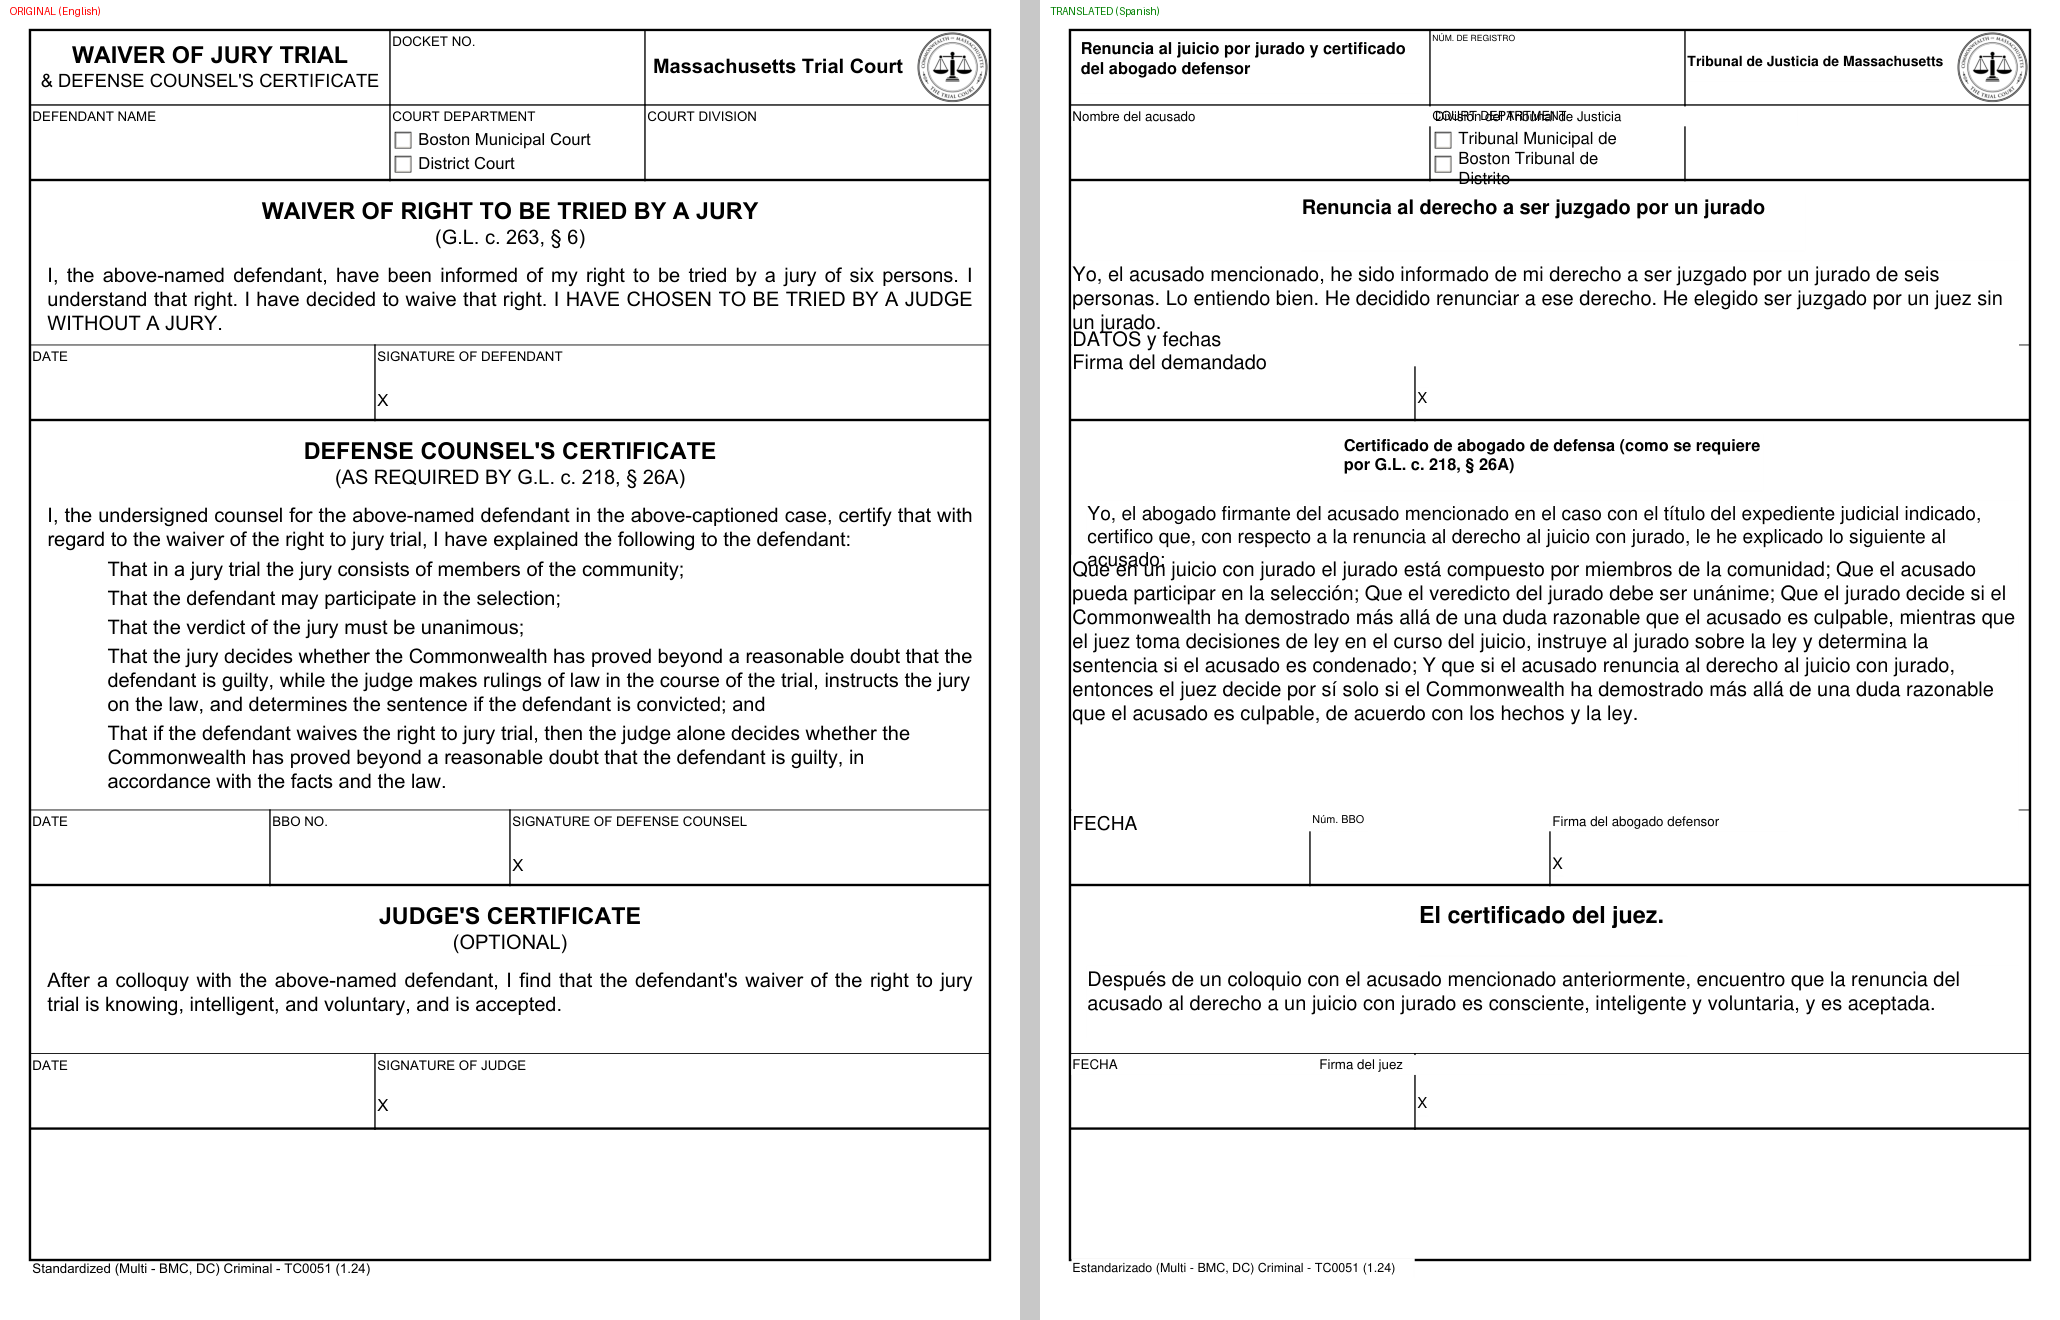

In [ ]:
# ============================================================
# CELL 11: VISUAL COMPARISON & DOWNLOAD
# Renders page 1 of original vs translated side-by-side for a
# quick visual sanity check, then downloads the output PDF.
# ============================================================

def show_comparison(original_path, translated_path, page_num=0, dpi=120):
    zoom = dpi / 72
    mat  = pymupdf.Matrix(zoom, zoom)
    orig_doc  = pymupdf.open(original_path)
    trans_doc = pymupdf.open(translated_path)
    pg        = min(page_num, len(orig_doc)-1, len(trans_doc)-1)

    orig_pix  = orig_doc[pg].get_pixmap(matrix=mat)
    trans_pix = trans_doc[pg].get_pixmap(matrix=mat)
    orig_img  = Image.frombytes("RGB", (orig_pix.width,  orig_pix.height),  orig_pix.samples)
    trans_img = Image.frombytes("RGB", (trans_pix.width, trans_pix.height), trans_pix.samples)

    max_h  = max(orig_img.height, trans_img.height)
    canvas = Image.new("RGB", (orig_img.width + trans_img.width + 20, max_h), (200, 200, 200))
    canvas.paste(orig_img,  (0, 0))
    canvas.paste(trans_img, (orig_img.width + 20, 0))

    draw = ImageDraw.Draw(canvas)
    draw.text((10, 5),                      "ORIGINAL (English)",   fill=(255, 0, 0))
    draw.text((orig_img.width + 30, 5),     "TRANSLATED (Spanish)", fill=(0, 128, 0))

    out_path = os.path.join(WORK_DIR, "comparison.png")
    canvas.save(out_path)
    display(IPImage(out_path))
    orig_doc.close()
    trans_doc.close()

print("🖼️  Page 1 — Original vs Translated:")
show_comparison(INPUT_PDF, OUTPUT_PDF, page_num=0)

# files.download(OUTPUT_PDF)
# print("✅ Downloaded: courtaccess_translated.pdf")